# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# Colab bootstrap: mount Drive and run from submission_2A202602505/code/ so REPO_ROOT="../.." and OUT_DIR=".." resolve
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB: from google.colab import drive; drive.mount("/content/drive")
if IN_COLAB: os.chdir("/content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602505/code")
if os.getcwd() not in sys.path: sys.path.insert(0, os.getcwd())
# %load_ext autoreload
# %autoreload 2
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602505/code


In [2]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess, math
import numpy as np, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/, scripts/, templates/), tính từ submission_2A202602505/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_2A202602505/)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"torch {torch.__version__} | device = {device}" + (f" | GPU = {torch.cuda.get_device_name(0)}" if device == "cuda" else ""))
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.11.0+cu130 | device = cuda | GPU = Tesla T4


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [3]:
# Part 0: tạo train.npz / eval.npz từ metadata (script tự kiểm tra tính toàn vẹn; chạy lại cho kết quả y hệt)
r = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, capture_output=True,
                   text=True, encoding="utf-8", env={**os.environ, "PYTHONIOENCODING": "utf-8"})
print(r.stdout)

# Tách val 20% từ train (phân tầng, seed 42), chuẩn hoá 10 cột số bằng mean/std của X_tr, đưa lên device
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert (len(data["X_tr"]), len(data["X_val"]), len(data["X_eval"])) == (371_847, 92_962, 116_203)

num = data["X_tr"][:, :10]
print("\nmean 10 cột số trên X_tr:", np.round(num.mean(0).cpu().numpy(), 4))
print("std  10 cột số trên X_tr:", np.round(num.std(0).cpu().numpy(), 4))
assert num.mean(0).abs().max() < 1e-3 and (num.std(0) - 1).abs().max() < 1e-3
assert set(torch.unique(data["X_tr"][:, 10:]).tolist()) <= {0.0, 1.0}   # 44 cột nhị phân giữ nguyên

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876

train_full 464,809 -> X_tr (371847, 54), X_val (92962, 54) | X_eval (116203, 54)
lớp   tr(%)   val(%)  eval(%)
  0  36.461   36.460   36.460
  1  48.760   48.760   48.760
  2   6.154    6.154    6.154
  3   0.473    0.472    0.472
  4   1.634    1.634    1.634
  5   2.989    2.989    2.989
  6   3.530    3.530    3.530
luôn đoán lớp đa số (1) -> accuracy trên val = 0.4876

mean 10 cột số trên X_tr: [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  10 cột số trên X_tr: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Nhận xét Part 0:** val được tách **từ train** (20%, phân tầng, seed 42), nên tỉ lệ lớp ở train/val/eval gần như trùng nhau.
Mean/std chỉ tính trên `X_tr`. Nếu tính cả trên val/eval, thống kê chuẩn hoá đã "nhìn thấy" chính dữ liệu dùng để đo (rò rỉ thông tin), nên điểm val/eval không còn đo đúng khả năng trên dữ liệu mới.
`X_eval` chỉ được biến đổi bằng mean/std đó và không tham gia chọn cấu hình hay dừng sớm. Lô cuối của mỗi epoch được giữ lại dù nhỏ hơn (371 847 = 726·512 + 135).
Mốc thấp nhất phải vượt: luôn đoán lớp đa số → accuracy ≈ 0,4876 trên val.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [4]:
# Part 1a/1b: M-base, số tham số và shape sau từng lớp
set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("số tham số:", n_params)
assert n_params == count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879

with torch.no_grad():
    h = torch.randn(8, 54, device=device)
    print(f"{'input':>8} -> {tuple(h.shape)}")
    for layer in model.net:
        h = layer(h)
        print(f"{type(layer).__name__:>8} -> {tuple(h.shape)}")
assert h.shape == (8, 7)

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879
   input -> (8, 54)
  Linear -> (8, 256)
    ReLU -> (8, 256)
  Linear -> (8, 128)
    ReLU -> (8, 128)
  Linear -> (8, 7)


In [5]:
# Part 1c-1: loss bước 0 trên val (eval mode, chưa cập nhật bước nào) phải ≈ ln 7
model.eval()
with torch.no_grad():
    logits0 = model(data["X_val"])
    step0_loss = F.cross_entropy(logits0, data["y_val"]).item()
print(f"loss bước 0 trên val = {step0_loss:.4f} | ln 7 = {math.log(7):.4f} | chênh = {step0_loss - math.log(7):+.4f}")
print(f"std của logit bước 0 = {logits0.std().item():.3f}")
print("std kích hoạt sau mỗi Linear (z1, z2, logits), lô val 4096 mẫu:",
      [round(s, 3) for s in activation_stats(model, data["X_val"][:4096])])

loss bước 0 trên val = 2.2691 | ln 7 = 1.9459 | chênh = +0.3232
std của logit bước 0 = 0.579
std kích hoạt sau mỗi Linear (z1, z2, logits), lô val 4096 mẫu: [0.661, 0.64, 0.577]


nhãn của 20 mẫu: [8, 9, 1, 0, 0, 1, 1]
loss bước 0 = 2.3581, bước 299 = 1.34e-06; accuracy trên 20 mẫu = 100%


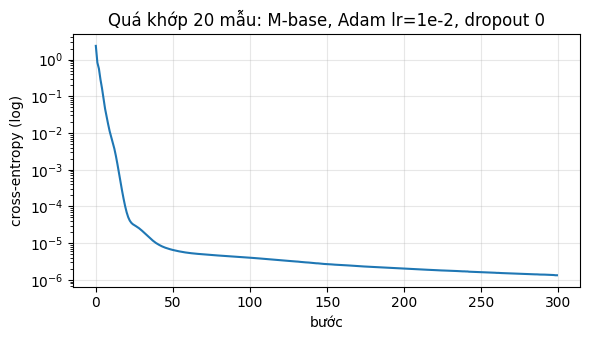

In [6]:
# Part 1c-2: quá khớp 20 mẫu (dropout tắt). Loss phải về gần 0 và accuracy 100% trên 20 mẫu đó
set_seed(1)
idx = torch.randperm(len(data["X_tr"]), generator=torch.Generator().manual_seed(0))[:20].to(device)
x20, y20 = data["X_tr"][idx], data["y_tr"][idx]
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
opt = torch.optim.Adam(tiny.parameters(), lr=1e-2)
losses = []
for step in range(300):
    loss = F.cross_entropy(tiny(x20), y20)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    losses.append(loss.item())
with torch.no_grad():
    acc20 = (tiny(x20).argmax(1) == y20).float().mean().item()
print(f"nhãn của 20 mẫu: {torch.bincount(y20, minlength=7).tolist()}")
print(f"loss bước 0 = {losses[0]:.4f}, bước {len(losses) - 1} = {losses[-1]:.2e}; accuracy trên 20 mẫu = {acc20:.0%}")

plt.figure(figsize=(6, 3.5))
plt.semilogy(losses)
plt.xlabel("bước"); plt.ylabel("cross-entropy (log)")
plt.title("Quá khớp 20 mẫu: M-base, Adam lr=1e-2, dropout 0")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
assert losses[-1] < 1e-2 and acc20 == 1.0

In [7]:
# Part 1d: sau một lần backward, mọi tham số phải có gradient khác None và khác 0
model.train()
model.zero_grad(set_to_none=True)
F.cross_entropy(model(data["X_tr"][:512]), data["y_tr"][:512]).backward()
for name, (pname, p) in zip(["W1", "b1", "W2", "b2", "W3", "b3"], model.named_parameters()):
    assert p.grad is not None, f"{name}: grad là None"
    gn = p.grad.norm().item()
    print(f"{name}  {pname:<12} {str(tuple(p.shape)):<11} grad norm = {gn:.4e}")
    assert gn > 0, f"{name}: grad bằng 0"

W1  net.0.weight (256, 54)   grad norm = 5.0705e-01
b1  net.0.bias   (256,)      grad norm = 3.4224e-01
W2  net.2.weight (128, 256)  grad norm = 2.0212e+00
b2  net.2.bias   (128,)      grad norm = 4.4387e-01
W3  net.4.weight (7, 128)    grad norm = 1.9605e+00
b3  net.4.bias   (7,)        grad norm = 5.7246e-01


**Nhận xét Part 1:**
- Model `M-base` có đúng 47 879 tham số, logits `(8, 7)`, không có softmax trong model.
- Loss bước 0 trên val = 2,2691, cao hơn ln 7 = 1,9459 khoảng 0,32. ln 7 chỉ đúng khi mọi logit ≈ 0 (softmax đều). Với He init, logit bước 0 có std ≈ 0,58, nên softmax đã nghiêng ngẫu nhiên về vài lớp. Lớp 0 và 1 chiếm 85% dữ liệu: nghiêng về chúng thì loss thấp hơn ln 7, nghiêng về lớp nhỏ thì cao hơn. Vì vậy mức lệch phụ thuộc seed: seed 2 cho 1,9782, seed 3 cho 1,9005 (thấp hơn ln 7), còn `normal(0,01)` với logit ≈ 0 cho đúng 1,9460 (Chủ đề 7). Lệch cỡ 0,3 là bình thường; lỗi nhãn hay lỗi chuẩn hoá sẽ cho loss lớn hơn nhiều.
- Quá khớp 20 mẫu (Adam lr 1e-2, dropout 0): loss từ 2,3581 xuống 1,34e-06 sau 300 bước, accuracy 100%. Forward, loss, backward và bước cập nhật được nối đúng, và model đủ sức nhớ dữ liệu.
- Sau một lần backward, cả 6 tensor tham số (W1…b3) đều có gradient khác 0 (norm từ 0,34 đến 2,02): gradient chảy tới mọi lớp.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [8]:
# ===== Tiện ích cho Part 2-4: chạy một cfg -> lưu results/<exp_id>.json -> vẽ figures/<exp_id>.png =====
import pandas as pd
from IPython.display import Image, display

USE_CACHE = True   # Colab hay ngắt kết nối: exp_id đã có JSON với ĐÚNG cfg này thì đọc lại thay vì chạy lại
QUICK = os.environ.get("LAB_QUICK") == "1"   # chỉ để thử notebook nhanh (1 epoch, 20 000 mẫu train); mặc định tắt
if QUICK:
    data = {**data, "X_tr": data["X_tr"][:20_000], "y_tr": data["y_tr"][:20_000]}
RESULTS = {}       # exp_id -> result


def _norm_cfg(c):
    return json.loads(json.dumps({**DEFAULT_CFG, **c, "hidden": list(c.get("hidden", DEFAULT_CFG["hidden"]))}))


def run(cfg, force=False, show=False):
    """Chạy (hoặc đọc lại từ JSON) một thí nghiệm, lưu JSON + ảnh, ghi vào RESULTS."""
    cfg = {**DEFAULT_CFG, **cfg}
    if QUICK:
        cfg["epochs"] = 1
    path = f"{OUT_DIR}/results/{cfg['exp_id']}.json"
    cached = None
    if USE_CACHE and not force and os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            cached = json.load(f)
        if _norm_cfg(cached["cfg"]) != _norm_cfg(cfg):
            print(f"[{cfg['exp_id']}] cfg khác file đã lưu -> chạy lại")
            cached = None
    if cached is not None:
        cached["cfg"]["hidden"] = tuple(cached["cfg"]["hidden"])
        res, s = cached, cached["summary"]
        print(f"[{cfg['exp_id']}] đọc lại {path}: best epoch {s['best_epoch']} | val acc {s['val_acc']:.4f} | "
              f"val macro-F1 {s['val_macro_f1']:.4f}")
    else:
        res = run_experiment(cfg, data)
        save_result(res, f"{OUT_DIR}/results")
    plot_run(res, f"{OUT_DIR}/figures/{cfg['exp_id']}.png")
    RESULTS[cfg["exp_id"]] = res
    if show:
        display(Image(f"{OUT_DIR}/figures/{cfg['exp_id']}.png"))
    return res


def f1(exp_id):
    return RESULTS[exp_id]["summary"]["val_macro_f1"]


def report(ids):
    """Bảng tóm tắt; khi đã có baseline nhiều seed thì thêm chênh lệch val macro-F1 so với trung bình baseline và 2σ."""
    rows = []
    for i in ids:
        s = RESULTS[i]["summary"]
        row = {"exp_id": i, "step0_loss": s["step0_loss"], "best_epoch": s["best_epoch"],
               "best_val_loss": s["best_val_loss"], "final_train_loss": s["final_train_loss"],
               "final_val_loss": s["final_val_loss"], "val_acc": s["val_acc"], "val_macro_f1": s["val_macro_f1"],
               "s/epoch": s["time_per_epoch_s"], "peak_mem_MB": s["peak_mem_MB"],
               "Δmem_MB": s["peak_mem_MB"] - s["base_mem_MB"], "diverged": s["diverged"]}
        if "NOISE_F1" in globals():
            row["Δf1_vs_base"] = s["val_macro_f1"] - BASE_F1_MEAN
            row["vượt 2σ?"] = "Có" if abs(row["Δf1_vs_base"]) > NOISE_F1 else "Không"
        rows.append(row)
    display(pd.DataFrame(rows).set_index("exp_id").round(4))

In [9]:
# Part 2: chọn lr cho baseline (SGD+momentum 0.9, M-base, He, batch 512, 20 epoch, seed 1) CHỈ bằng VAL macro-F1.
# Mỗi lần quét cũng là thí nghiệm của chủ đề optimizer (SGD+momentum ở 4 lr): mỗi lần một dòng trong bảng + một ảnh.
LR_GRID = {"sgd_momentum": [0.01, 0.03, 0.1, 0.3]}
SHORT = {"sgd": "sgd", "sgd_momentum": "sgdm", "adam": "adam", "adamw": "adamw"}


def opt_id(opt, lr):
    return f"opt-{SHORT[opt]}-lr{lr:g}"


def best_lr(opt):
    """lr có val macro-F1 cao nhất trong lưới của opt; cảnh báo nếu nó nằm ở biên lưới (nên thử thêm lr ngoài biên)."""
    lrs = LR_GRID[opt]
    lr = max(lrs, key=lambda v: f1(opt_id(opt, v)))
    if lr in (min(lrs), max(lrs)):
        print(f"chú ý: lr tốt nhất của {opt} ({lr:g}) nằm ở biên lưới {lrs} -> nên thử thêm một lr ngoài biên")
    return lr


for lr in LR_GRID["sgd_momentum"]:
    run({"exp_id": opt_id("sgd_momentum", lr), "group": "optimizer", "lr": lr,
         "description": f"SGD+momentum 0.9, lr={lr:g} (quét lr để chọn lr baseline)"})
report([opt_id("sgd_momentum", lr) for lr in LR_GRID["sgd_momentum"]])
BASE_LR = best_lr("sgd_momentum")
BASE_CFG = {**DEFAULT_CFG, "lr": BASE_LR}
print(f"lr baseline chọn theo val macro-F1: {BASE_LR:g}")

[opt-sgdm-lr0.01] ce | sgd_momentum lr=0.01 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.5756 | val 0.5797 acc 0.7546 f1 0.5135 | gn 0.430 (max 2.871) | 1.51s
  ep  5/20 | train 0.4431 | val 0.4486 acc 0.8120 f1 0.6271 | gn 0.788 (max 2.019) | 1.21s
  ep 10/20 | train 0.3816 | val 0.3890 acc 0.8364 f1 0.7168 | gn 1.120 (max 2.756) | 1.35s
  ep 15/20 | train 0.3378 | val 0.3468 acc 0.8568 f1 0.7457 | gn 1.289 (max 3.546) | 1.23s
  ep 20/20 | train 0.3185 | val 0.3294 acc 0.8647 f1 0.7454 | gn 1.315 (max 3.067) | 1.43s
  -> best epoch 19 | best val loss 0.3171 | val acc 0.8716 | val macro-F1 0.7637 | 1.33s/epoch
[opt-sgdm-lr0.03] ce | sgd_momentum lr=0.03 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.5153 | val 0.5166 acc 0.7797 f1 0.5692 | gn 0.529 (max 2.871) | 1.22s
  ep  5/20 | train 0.3852 | val 0.3929 acc 0.8347 f1 0.6918 | gn 0.905 (max 1.976) 

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged
exp_id,,,,,,,,,,,
opt-sgdm-lr0.01,2.2691,19,0.3171,0.3185,0.3294,0.8716,0.7637,1.3347,173.9185,16.8027,False
opt-sgdm-lr0.03,2.2691,20,0.2584,0.2431,0.2584,0.8959,0.8258,1.3275,174.1016,16.8027,False
opt-sgdm-lr0.1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2982,174.2847,16.8027,False
opt-sgdm-lr0.3,2.2691,20,0.2269,0.2002,0.2269,0.9096,0.8521,1.5419,174.4678,16.8027,False


lr baseline chọn theo val macro-F1: 0.1


[base-s1] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.4707 | val 0.4722 acc 0.7960 f1 0.6335 | gn 0.532 (max 2.871) | 1.25s
  ep  5/20 | train 0.3380 | val 0.3501 acc 0.8537 f1 0.7685 | gn 0.588 (max 1.134) | 1.25s
  ep 10/20 | train 0.2682 | val 0.2854 acc 0.8845 f1 0.8214 | gn 0.578 (max 1.068) | 1.25s
  ep 15/20 | train 0.2353 | val 0.2530 acc 0.8990 f1 0.8371 | gn 0.576 (max 1.009) | 1.23s
  ep 20/20 | train 0.2091 | val 0.2314 acc 0.9085 f1 0.8584 | gn 0.565 (max 0.894) | 1.34s
  -> best epoch 20 | best val loss 0.2314 | val acc 0.9085 | val macro-F1 0.8584 | 1.31s/epoch


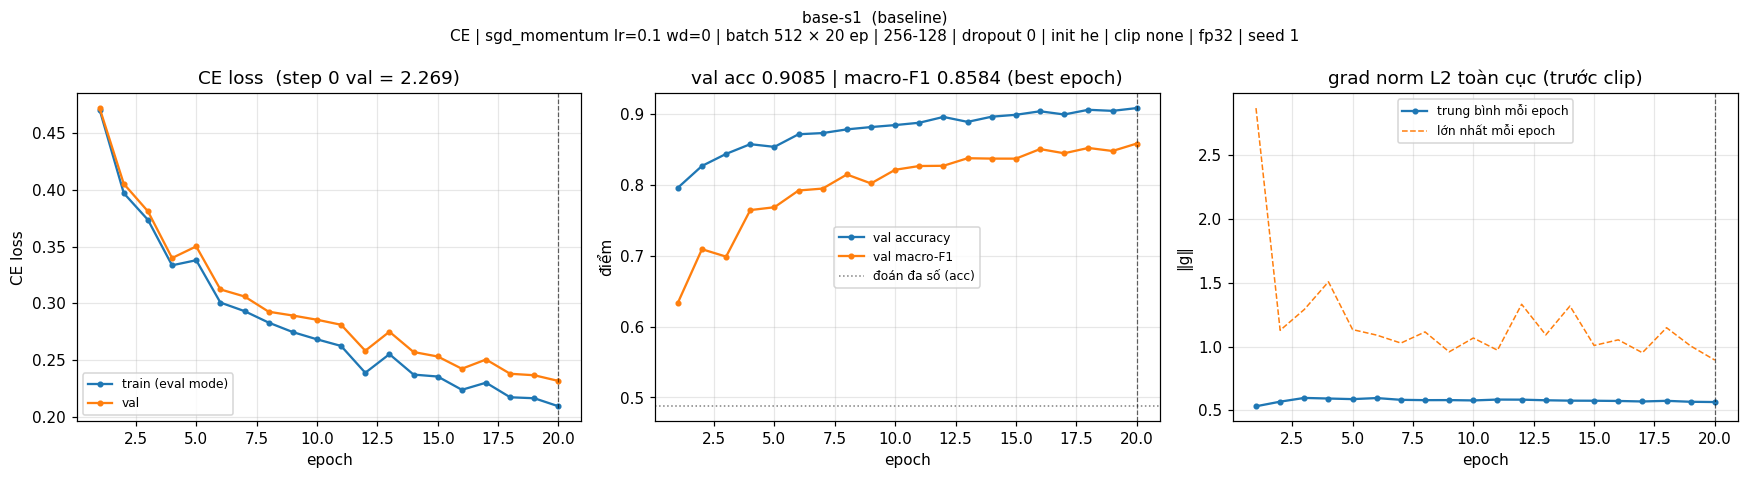

[base-s2] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 2 | step0 val loss 1.9782
  ep  1/20 | train 0.4749 | val 0.4820 acc 0.7936 f1 0.6298 | gn 0.520 (max 2.390) | 1.25s
  ep  5/20 | train 0.3254 | val 0.3328 acc 0.8632 f1 0.7739 | gn 0.550 (max 1.164) | 1.22s
  ep 10/20 | train 0.2619 | val 0.2763 acc 0.8877 f1 0.7975 | gn 0.562 (max 0.889) | 1.21s
  ep 15/20 | train 0.2226 | val 0.2389 acc 0.9033 f1 0.8467 | gn 0.544 (max 0.905) | 1.20s
  ep 20/20 | train 0.2032 | val 0.2261 acc 0.9098 f1 0.8552 | gn 0.538 (max 0.994) | 1.41s
  -> best epoch 20 | best val loss 0.2261 | val acc 0.9098 | val macro-F1 0.8552 | 1.29s/epoch
[base-s3] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 3 | step0 val loss 1.9005
  ep  1/20 | train 0.4604 | val 0.4651 acc 0.8020 f1 0.6592 | gn 0.526 (max 2.628) | 1.28s
  ep  5/20 | train 0.3126 | val 0.3211 acc 0.8680 f1 0.7807 | gn 0.590 (max 1.119) | 1.46s
  ep 10/20

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.3072,174.6509,16.8027,False,0.0021,Không
base-s2,1.9782,20,0.2261,0.2032,0.2261,0.9098,0.8552,1.2880,174.8340,16.8027,False,-0.0010,Không
base-s3,1.9005,19,0.2275,0.2286,0.2532,0.9090,0.8551,1.3530,175.0171,16.8027,False,-0.0011,Không


val macro-F1 = 0.8562 ± 0.0019 (3 seed) -> ngưỡng nhiễu 2σ = 0.0037
val acc      = 0.9091 ± 0.0007 (mốc đoán đa số 0.4876)


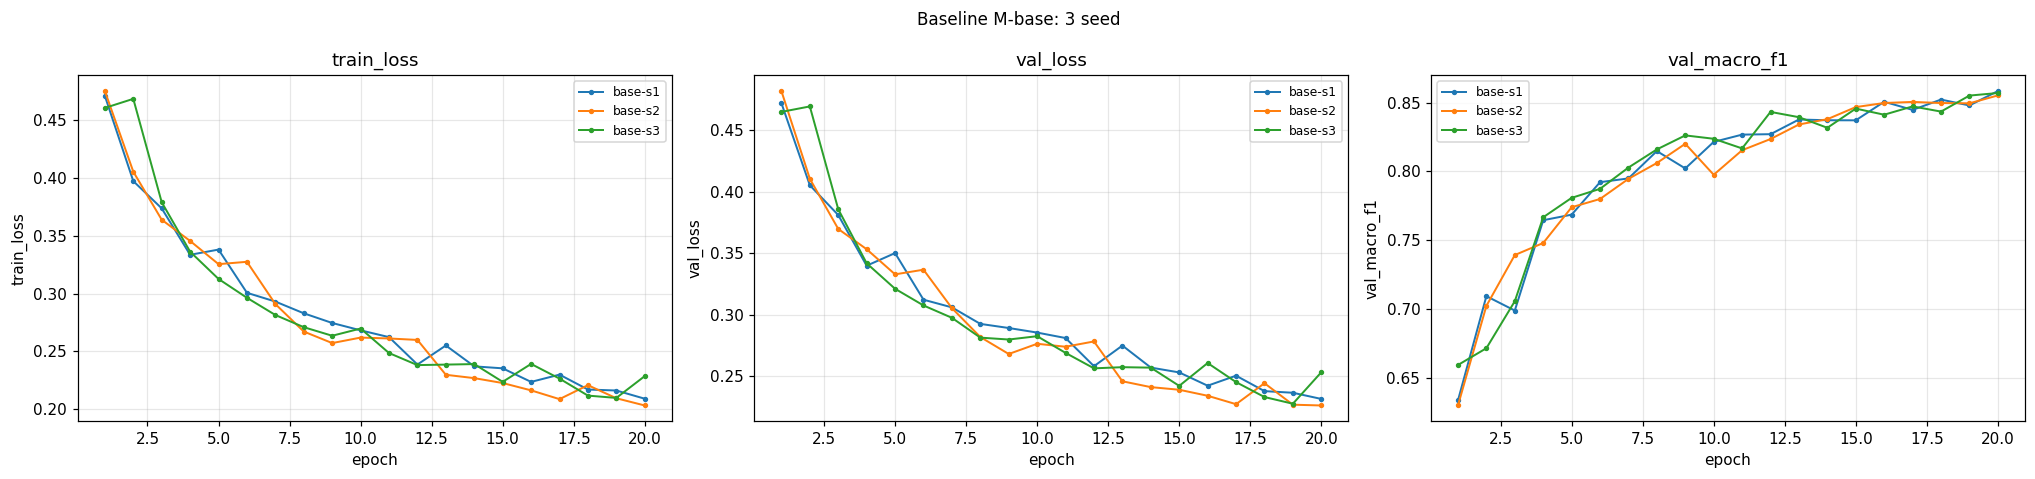

In [10]:
# Baseline với 3 seed để đo độ nhiễu: chênh lệch val macro-F1 nhỏ hơn 2σ không phải là bằng chứng.
BASE_IDS = ["base-s1", "base-s2", "base-s3"]
for seed, exp_id in zip((1, 2, 3), BASE_IDS):
    run({**BASE_CFG, "exp_id": exp_id, "group": "baseline", "seed": seed,
         "description": f"Baseline M-base, seed {seed}"}, show=(seed == 1))

f1s = np.array([f1(i) for i in BASE_IDS])
accs = np.array([RESULTS[i]["summary"]["val_acc"] for i in BASE_IDS])
BASE_F1_MEAN, BASE_F1_STD = f1s.mean(), f1s.std(ddof=1)   # ddof=1 giống STDEV ở sheet Seeds
NOISE_F1 = 2 * BASE_F1_STD
report(BASE_IDS)
print(f"val macro-F1 = {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f} (3 seed) -> ngưỡng nhiễu 2σ = {NOISE_F1:.4f}")
print(f"val acc      = {accs.mean():.4f} ± {accs.std(ddof=1):.4f} (mốc đoán đa số 0.4876)")
assert accs.min() > 0.4876, "baseline không vượt mốc đoán đa số -> có lỗi"

plot_compare([RESULTS[i] for i in BASE_IDS], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_baseline.png", "Baseline M-base: 3 seed")
display(Image(f"{OUT_DIR}/figures/compare_baseline.png"))

**Nhận xét baseline:**
- lr chọn bằng val macro-F1 trên lưới {0,01; 0,03; 0,1; 0,3}: lr = 0,1 cho 0,8584, cao nhất và không nằm ở biên lưới (0,3: 0,8521; 0,03: 0,8258; 0,01: 0,7637, đi quá chậm trong 20 epoch).
- Hình dạng đường cong: train loss và val loss cùng giảm tới cuối (best epoch 20 / 20 / 19 với 3 seed). Khoảng cách val − train loss ở epoch cuối chỉ ≈ 0,02 (`base-s1`: 0,2314 − 0,2091). Model **chưa quá khớp**; nó còn underfit vì thiếu bước huấn luyện, nên thêm epoch hoặc giảm lr dần về cuối có lẽ còn tăng được. Đường cong có răng cưa nhỏ do lr cố định 0,1 và nhiễu mini-batch (ví dụ `base-s3`: val loss epoch 20 = 0,2532, cao hơn 0,2275 ở epoch 19).
- val acc = 0,9091 ± 0,0007, cao xa mốc đoán đa số 0,4876. val macro-F1 = 0,8562 ± 0,0019 thấp hơn accuracy vì macro-F1 tính mỗi lớp như nhau, và các lớp nhỏ (3, 4, 5) bị đoán kém hơn.
- Nhiễu seed: σ = 0,0019 (3 seed, ddof = 1), nên ngưỡng 2σ = 0,0037. Ở Part 3, chênh lệch val macro-F1 so với trung bình baseline nhỏ hơn 0,0037 được coi là chưa kết luận được. Hạn chế: σ chỉ ước từ 3 seed, và mỗi thí nghiệm ở Part 3 chỉ chạy 1 seed.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Chủ đề 1 — Hàm mất mát (`loss`): CE → MSE trên one-hot
**Dự đoán trước:** MSE sẽ cho val macro-F1 thấp hơn CE rõ rệt (vượt 2σ), còn accuracy giảm ít hơn. Với CE, gradient theo logit là (softmax − one-hot), vẫn lớn khi model đoán sai một cách tự tin. Với MSE trên logit, gradient là 2(z − y)/(B·7): nhỏ hơn nhiều ở cùng lr, và còn kéo logit của các lớp sai về đúng 0 thay vì chỉ cần thấp hơn lớp đúng. Các lớp ít mẫu (3, 4, 5) đóng góp ít vào tổng MSE nên sẽ bị thiệt nhất.

[loss-mse] mse | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | step0 val loss 0.6359
  ep  1/20 | train 0.0483 | val 0.0486 acc 0.7634 f1 0.4626 | gn 0.060 (max 2.284) | 1.37s
  ep  5/20 | train 0.0378 | val 0.0384 acc 0.8192 f1 0.5918 | gn 0.076 (max 0.142) | 1.27s
  ep 10/20 | train 0.0329 | val 0.0337 acc 0.8457 f1 0.6772 | gn 0.089 (max 0.173) | 1.29s
  ep 15/20 | train 0.0299 | val 0.0306 acc 0.8627 f1 0.7219 | gn 0.098 (max 0.176) | 1.45s
  ep 20/20 | train 0.0285 | val 0.0294 acc 0.8721 f1 0.7317 | gn 0.102 (max 0.201) | 1.34s
  -> best epoch 19 | best val loss 0.0294 | val acc 0.8713 | val macro-F1 0.7329 | 1.38s/epoch


,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.3072,174.6509,16.8027,False,0.0021,Không
loss-mse,0.6359,19,0.0294,0.0285,0.0294,0.8713,0.7329,1.3838,175.2036,16.8062,False,-0.1233,Có


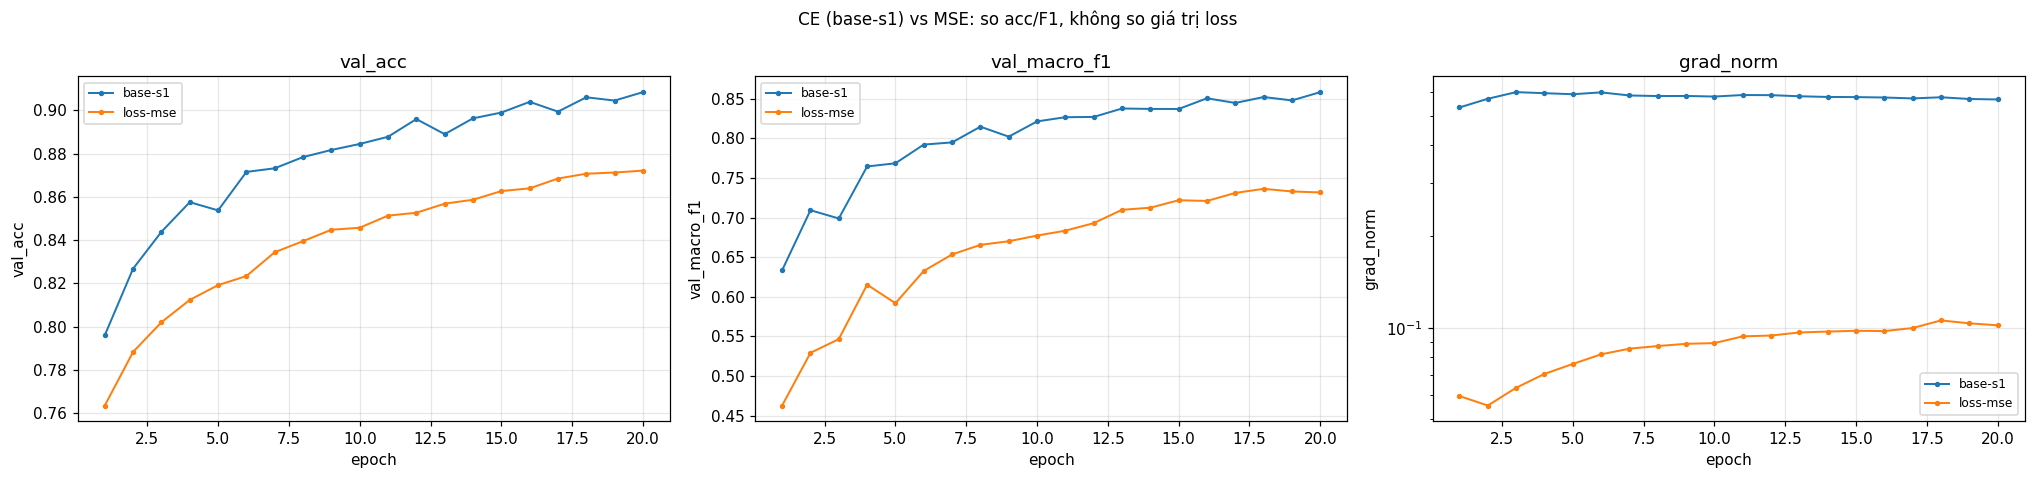

In [11]:
# Chủ đề 1 — loss: chỉ đổi CE -> MSE (cùng lr, seed, 20 epoch). MSE = F.mse_loss(logits, one_hot(y)):
# trung bình trên B×7 phần tử, không có hệ số 1/2 (= nn.MSELoss mặc định). So acc/macro-F1, KHÔNG so giá trị loss.
run({**BASE_CFG, "exp_id": "loss-mse", "group": "loss", "loss": "mse",
     "description": "MSE trên one-hot thay cho CE",
     "notes": "MSE trung bình trên B×7 phần tử, không hệ số 1/2; khác thang đo CE nên chỉ so acc/F1"})
report(["base-s1", "loss-mse"])
plot_compare([RESULTS["base-s1"], RESULTS["loss-mse"]], ["val_acc", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_loss.png", "CE (base-s1) vs MSE: so acc/F1, không so giá trị loss")
display(Image(f"{OUT_DIR}/figures/compare_loss.png"))

**Đối chiếu sau khi chạy:** khớp dự đoán. `loss-mse` cho val macro-F1 0,7329, thấp hơn trung bình baseline 0,1233 (vượt xa 2σ = 0,0037), trong khi val acc chỉ giảm từ 0,9085 xuống 0,8713: phần mất chủ yếu nằm ở các lớp nhỏ. Cơ chế thấy trên `compare_loss.png`: grad_norm của MSE chỉ 0,06–0,10, so với 0,53–0,58 của CE. Cùng lr 0,1 nhưng bước cập nhật nhỏ hơn 5–9 lần, và đường F1 của MSE vẫn đang đi lên ở epoch 20. Không so giá trị loss (0,0294 với 0,2314) vì hai hàm khác thang đo. Hạn chế: lr 0,1 được chọn cho CE; với lr chỉnh riêng cho MSE, khoảng cách có thể nhỏ hơn (chưa thử, 1 seed).

### Chủ đề 2 — Bộ tối ưu (`optimizer`): SGD, SGD+momentum, Adam, AdamW, mỗi bộ ≥ 3 lr
**Dự đoán trước:** khi mỗi bộ được chỉnh lr riêng, Adam/AdamW sẽ ngang hoặc nhỉnh hơn SGD+momentum trong 20 epoch. Adam chia bước theo √v của từng tham số, nên các trọng số ít nhận gradient (nối với các cột nhị phân hiếm như soil type) vẫn học nhanh. SGD không momentum ở lr 0,1 sẽ chậm hẳn. Nếu tăng lr lên ~10 lần (= 1/(1 − μ)), bước hiệu dụng tương đương SGD+momentum nên kết quả sẽ gần nhau. AdamW (wd 0,01) gần như giống Adam vì baseline chưa quá khớp. Nếu không chỉnh lr, kết luận sẽ phụ thuộc vào lr chung được chọn chứ không phản ánh optimizer.

[opt-sgd-lr0.1] ce | sgd lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.5936 | val 0.5959 acc 0.7416 f1 0.5127 | gn 0.579 (max 2.871) | 1.20s
  ep  5/20 | train 0.4625 | val 0.4673 acc 0.8031 f1 0.6451 | gn 0.858 (max 2.286) | 1.19s
  ep 10/20 | train 0.4150 | val 0.4219 acc 0.8235 f1 0.6850 | gn 0.988 (max 2.606) | 1.19s
  ep 15/20 | train 0.3533 | val 0.3607 acc 0.8507 f1 0.7301 | gn 0.982 (max 3.131) | 1.21s
  ep 20/20 | train 0.4057 | val 0.4147 acc 0.8266 f1 0.6817 | gn 1.049 (max 2.734) | 1.21s
  -> best epoch 18 | best val loss 0.3429 | val acc 0.8580 | val macro-F1 0.7397 | 1.28s/epoch
[opt-sgd-lr0.3] ce | sgd lr=0.3 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.5415 | val 0.5419 acc 0.7655 f1 0.5741 | gn 0.556 (max 2.871) | 1.30s
  ep  5/20 | train 0.4195 | val 0.4258 acc 0.8198 f1 0.7021 | gn 0.640 (max 1.711) | 1.21s
  ep 10/20 | tra

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
opt-sgdm-lr0.01,2.2691,19,0.3171,0.3185,0.3294,0.8716,0.7637,1.3347,173.9185,16.8027,False,-0.0925,Có
opt-sgdm-lr0.03,2.2691,20,0.2584,0.2431,0.2584,0.8959,0.8258,1.3275,174.1016,16.8027,False,-0.0304,Có
opt-sgdm-lr0.1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2982,174.2847,16.8027,False,0.0021,Không
opt-sgdm-lr0.3,2.2691,20,0.2269,0.2002,0.2269,0.9096,0.8521,1.5419,174.4678,16.8027,False,-0.0042,Có
opt-sgd-lr0.1,2.2691,18,0.3429,0.4057,0.4147,0.8580,0.7397,1.2801,174.8340,16.6196,False,-0.1165,Có
opt-sgd-lr0.3,2.2691,19,0.2890,0.3412,0.3581,0.8809,0.8008,1.3000,175.0171,16.6196,False,-0.0554,Có
opt-sgd-lr1,2.2691,15,0.2662,0.2881,0.3140,0.8924,0.8100,1.2577,175.2002,16.6196,False,-0.0462,Có
opt-adam-lr0.0003,2.2691,20,0.3080,0.2979,0.3080,0.8761,0.7955,1.4779,175.7495,16.9858,False,-0.0607,Có
opt-adam-lr0.001,2.2691,18,0.2420,0.2269,0.2491,0.9033,0.8437,1.4474,175.9326,16.9858,False,-0.0125,Có


lr tốt nhất của mỗi optimizer (theo val macro-F1): {'sgd_momentum': 'opt-sgdm-lr0.1', 'sgd': 'opt-sgd-lr1', 'adam': 'opt-adam-lr0.003', 'adamw': 'opt-adamw-lr0.003'}


,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
opt-sgdm-lr0.1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2982,174.2847,16.8027,False,0.0021,Không
opt-sgd-lr1,2.2691,15,0.2662,0.2881,0.3140,0.8924,0.8100,1.2577,175.2002,16.6196,False,-0.0462,Có
opt-adam-lr0.003,2.2691,18,0.2101,0.1828,0.2110,0.9178,0.8683,1.4362,176.1157,16.9858,False,0.0121,Có
opt-adamw-lr0.003,2.2691,20,0.2131,0.1902,0.2131,0.9137,0.8757,1.5033,176.6650,16.9858,False,0.0195,Có


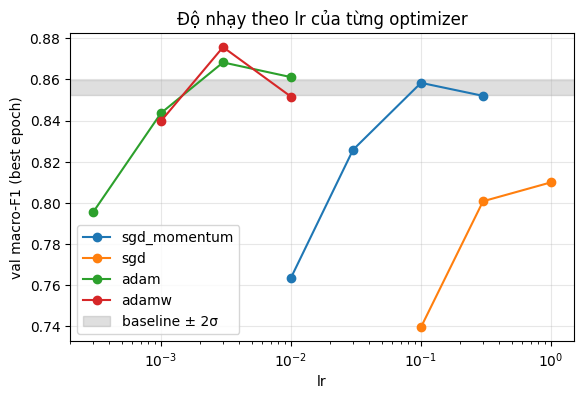

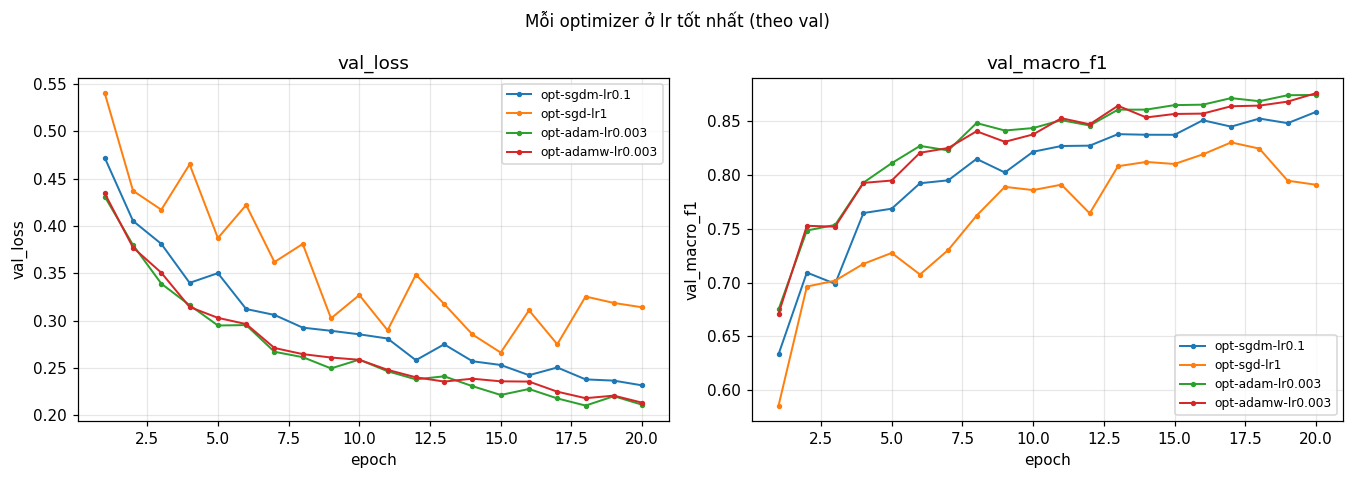

In [12]:
# Chủ đề 2 — optimizer: mỗi bộ ≥ 3 lr (cách nhau ~3 lần), so ở lr tốt nhất của mỗi bộ (theo VAL).
# SGD+momentum đã quét ở Part 2. SGD không momentum cần lr lớn hơn (~1/(1-μ) = 10 lần) mới có cùng bước hiệu dụng.
# Adam/AdamW: betas=(0.9, 0.999), eps=1e-8; AdamW weight_decay=0.01 (tách riêng).
LR_GRID.update({"sgd": [0.1, 0.3, 1.0], "adam": [3e-4, 1e-3, 3e-3, 1e-2], "adamw": [1e-3, 3e-3, 1e-2]})
NAMES = {"sgd": "SGD (không momentum)", "adam": "Adam", "adamw": "AdamW wd=0.01"}
for opt in ("sgd", "adam", "adamw"):
    for lr in LR_GRID[opt]:
        run({**BASE_CFG, "exp_id": opt_id(opt, lr), "group": "optimizer", "optimizer": opt, "lr": lr,
             "weight_decay": 0.01 if opt == "adamw" else 0.0, "description": f"{NAMES[opt]}, lr={lr:g}"})
OPT_IDS = {opt: [opt_id(opt, lr) for lr in lrs] for opt, lrs in LR_GRID.items()}
BEST_OPT = {opt: opt_id(opt, best_lr(opt)) for opt in LR_GRID}
report([i for ids in OPT_IDS.values() for i in ids])
print("lr tốt nhất của mỗi optimizer (theo val macro-F1):", BEST_OPT)
report(list(BEST_OPT.values()))

fig, ax = plt.subplots(figsize=(6.5, 4))
for opt, lrs in LR_GRID.items():
    ax.plot(lrs, [f1(opt_id(opt, lr)) for lr in lrs], "o-", label=opt)
ax.axhspan(BASE_F1_MEAN - NOISE_F1, BASE_F1_MEAN + NOISE_F1, color="gray", alpha=0.25, label="baseline ± 2σ")
ax.set_xscale("log"); ax.set_xlabel("lr"); ax.set_ylabel("val macro-F1 (best epoch)")
ax.set_title("Độ nhạy theo lr của từng optimizer"); ax.grid(alpha=0.3); ax.legend()
fig.savefig(f"{OUT_DIR}/figures/compare_optimizer_lr.png", dpi=110, bbox_inches="tight"); plt.show()
plot_compare([RESULTS[i] for i in BEST_OPT.values()], ["val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_optimizer.png", "Mỗi optimizer ở lr tốt nhất (theo val)")
display(Image(f"{OUT_DIR}/figures/compare_optimizer.png"))

**Đối chiếu sau khi chạy:** khớp một phần. Mỗi optimizer ở lr tốt nhất của nó (theo val):

| optimizer | exp_id | lr | val macro-F1 | best epoch |
|---|---|---|---|---|
| SGD+momentum | `opt-sgdm-lr0.1` | 0,1 | 0,8584 | 20 |
| SGD | `opt-sgd-lr1` | 1 | 0,8100 | 15 |
| Adam | `opt-adam-lr0.003` | 3e-3 | 0,8683 | 18 |
| AdamW (wd 0,01) | `opt-adamw-lr0.003` | 3e-3 | 0,8757 | 20 |

- Khớp: Adam và AdamW vượt SGD+momentum (+0,0121 và +0,0195 so với trung bình baseline, vượt 2σ). Cả hai đều tốt nhất ở 3e-3 và kém đi ở 1e-2.
- Khác: SGD không momentum ở lr = 1 (cùng bước hiệu dụng với SGD+momentum lr 0,1) vẫn kém 0,046 và răng cưa: best epoch 15, sau đó val loss tăng lại (0,2662 → 0,3140 ở epoch 20). Momentum không chỉ phóng to bước mà còn lấy trung bình gradient qua ~10 bước, nên lọc bớt nhiễu mini-batch; SGD trần với lr lớn nhận trọn nhiễu đó. lr = 1 nằm ở biên lưới nên lr tốt nhất của SGD có thể chưa được tìm thấy.
- Khác: AdamW hơn Adam 0,0074. Mức này vượt 2σ, nhưng mỗi optimizer chỉ chạy 1 seed, nên chưa đủ để kết luận về tác dụng của weight decay.
- Nếu không chỉnh lr (mọi bộ dùng lr 0,1 của baseline), SGD chỉ được 0,7397, và kết luận "SGD kém hơn 0,12" sẽ sai: phần lớn khoảng cách đó do lr. Trên `compare_optimizer_lr.png`, lr nhỏ hơn lr tốt nhất 10 lần làm mất nhiều nhất (SGD+momentum 0,01: 0,7637; Adam 3e-4: 0,7955) vì đi quá chậm trong 20 epoch, còn phía lr lớn chỉ giảm ít (SGD+momentum 0,3: 0,8521; Adam 1e-2: 0,8611).

### Chủ đề 3 — Hyper-parameter (`hparam`): batch size, độ rộng, độ sâu
**Dự đoán trước:**
- batch 128, giữ lr: số bước gấp 4 (58 120 so với 14 540 trong 20 epoch), nên F1 nhỉnh hơn baseline, nhưng mỗi epoch chậm hơn ~4 lần vì GPU xử lý lô nhỏ kém hiệu quả.
- batch 2048, giữ lr: chỉ 3 640 bước, model chưa hội tụ nên F1 giảm rõ (vượt 2σ); mỗi epoch nhanh hơn nhiều.
- batch 2048, lr × 4 + warmup 1 epoch: bước lớn hơn bù cho số bước ít hơn (quy tắc tăng lr theo lô), F1 về gần baseline mà vẫn nhanh.
- M-wide (161 287 tham số, ×3,4) và M-deep (55 687, ×1,16): baseline đang underfit, nên thêm dung lượng sẽ tăng F1 một chút (vượt 2σ). M-wide tốn bộ nhớ hơn; thời gian/epoch gần như không đổi vì GPU chưa bận.

[hp-batch128] ce | sgd_momentum lr=0.1 wd=0 | batch 128 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.4311 | val 0.4354 acc 0.8142 f1 0.6264 | gn 0.586 (max 3.173) | 4.97s
  ep  5/20 | train 0.3008 | val 0.3124 acc 0.8732 f1 0.7928 | gn 0.601 (max 5.145) | 5.34s
  ep 10/20 | train 0.2433 | val 0.2626 acc 0.8945 f1 0.8276 | gn 0.588 (max 1.686) | 5.45s
  ep 15/20 | train 0.2083 | val 0.2314 acc 0.9082 f1 0.8441 | gn 0.582 (max 1.608) | 5.48s
  ep 20/20 | train 0.2028 | val 0.2293 acc 0.9121 f1 0.8548 | gn 0.576 (max 1.011) | 5.23s
  -> best epoch 18 | best val loss 0.2263 | val acc 0.9116 | val macro-F1 0.8563 | 5.18s/epoch
[hp-batch2048] ce | sgd_momentum lr=0.1 wd=0 | batch 2048 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.5346 | val 0.5390 acc 0.7678 f1 0.5599 | gn 0.377 (max 2.881) | 0.39s
  ep  5/20 | train 0.3840 | val 0.3913 acc 0.8364 f1 0.6836 | gn 0.695 (max 1.789) | 0.31s


,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.3072,174.6509,16.8027,False,0.0021,Không
hp-batch128,2.2691,18,0.2263,0.2028,0.2293,0.9116,0.8563,5.1786,176.8174,16.7720,False,0.0000,Không
hp-batch2048,2.2691,18,0.2892,0.2771,0.2930,0.8830,0.8090,0.3268,177.2773,17.0488,False,-0.0472,Có
hp-batch2048-lrx4,2.2691,20,0.2332,0.2106,0.2332,0.9056,0.8536,0.3643,177.4604,17.0488,False,-0.0026,Không
hp-wide,1.9182,19,0.2021,0.1758,0.2043,0.9209,0.8725,1.3349,195.1279,34.1006,False,0.0162,Có
hp-deep,1.9099,20,0.1964,0.1680,0.1964,0.9222,0.8719,1.4704,178.1343,16.8936,False,0.0157,Có


batch  128: 2906 bước/epoch ->  58120 bước trong 20 epoch
batch  512:  727 bước/epoch ->  14540 bước trong 20 epoch
batch 2048:  182 bước/epoch ->   3640 bước trong 20 epoch


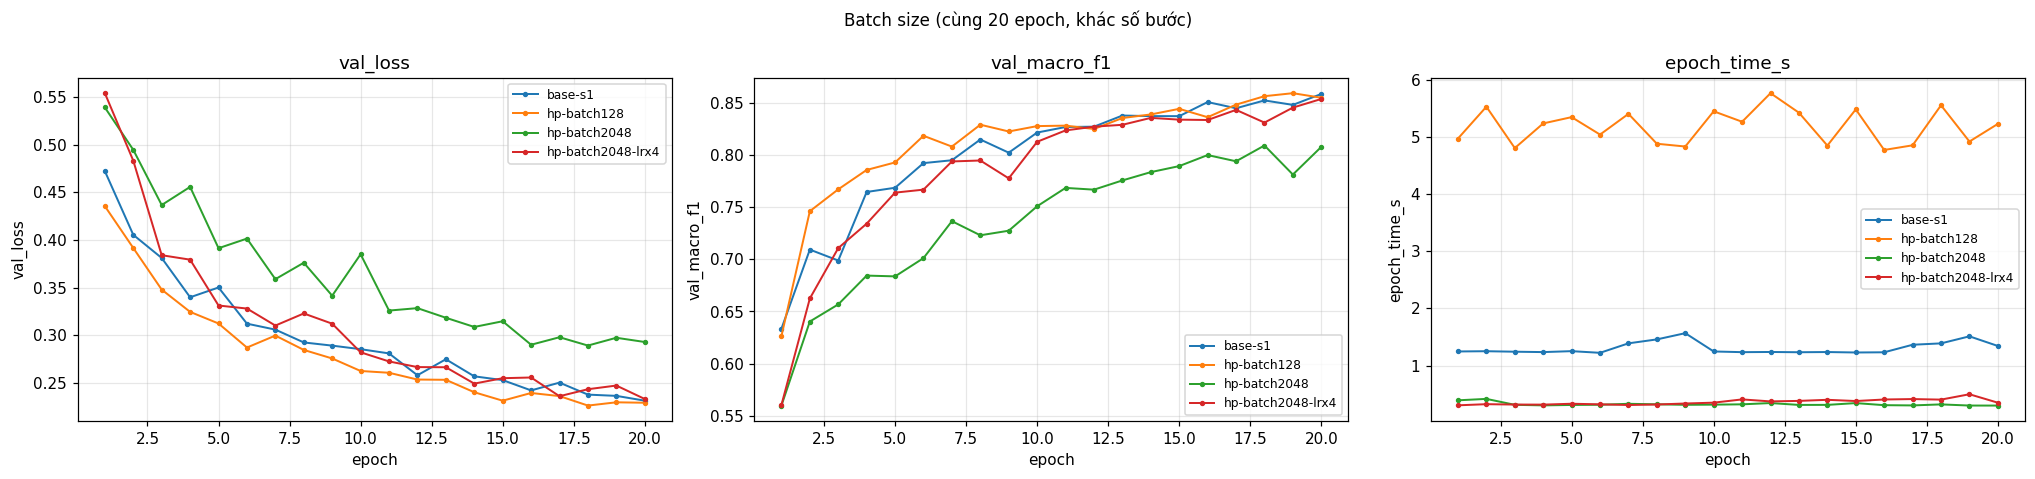

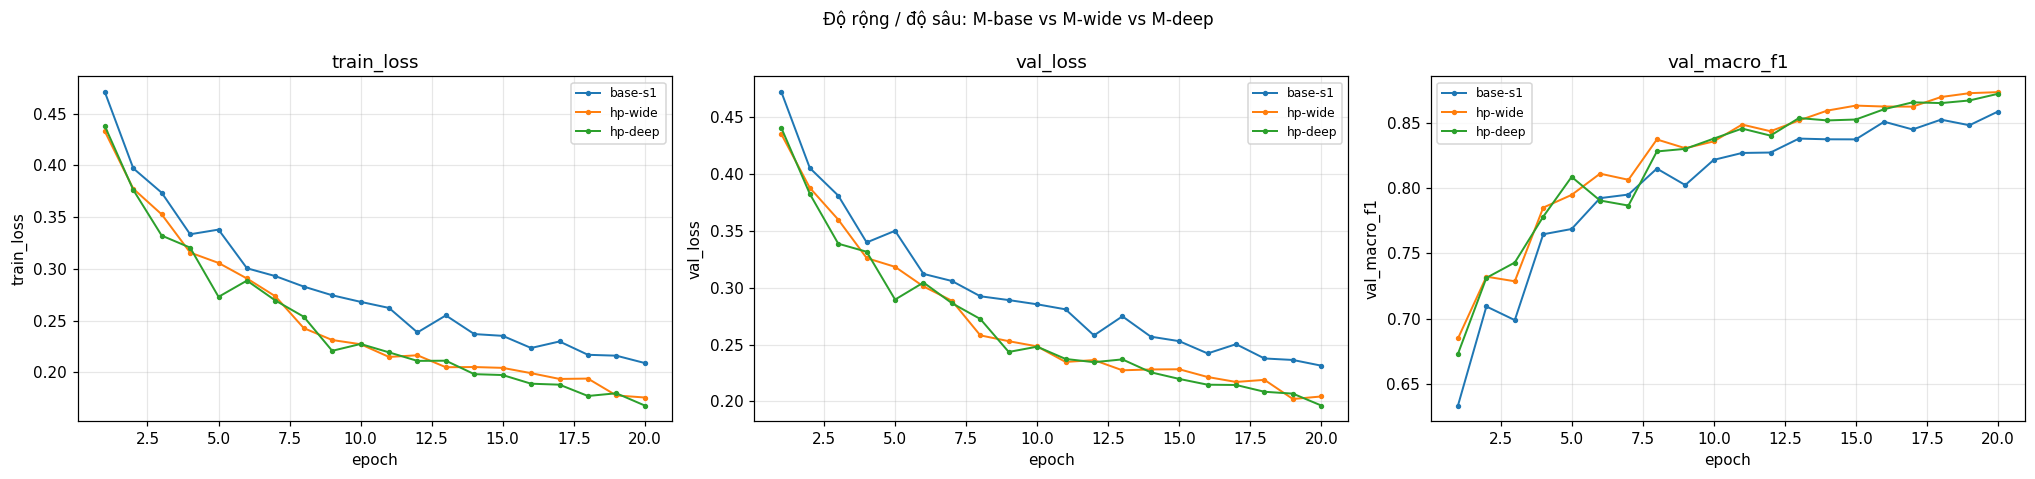

In [13]:
# Chủ đề 3 — hyper-parameter: batch size (cùng 20 epoch nhưng SỐ BƯỚC cập nhật khác nhau), độ rộng, độ sâu.
def steps(batch):
    return math.ceil(len(data["X_tr"]) / batch)


HP = [
    dict(exp_id="hp-batch128", batch=128, description="batch 128 (lr giữ nguyên)"),
    dict(exp_id="hp-batch2048", batch=2048, description="batch 2048 (lr giữ nguyên)"),
    dict(exp_id="hp-batch2048-lrx4", batch=2048, lr=4 * BASE_LR, scheduler="warmup", warmup_steps=steps(2048),
         description="batch 2048, lr ×4 (quy tắc tăng lr theo lô) + khởi động tuyến tính 1 epoch",
         notes="đổi có chủ đích batch ×4 và lr ×4, kèm warmup 1 epoch"),
    dict(exp_id="hp-wide", hidden=(512, 256), description="M-wide 54-512-256-7 (161 287 tham số)"),
    dict(exp_id="hp-deep", hidden=(256, 128, 64), description="M-deep 54-256-128-64-7 (55 687 tham số)"),
]
for c in HP:
    run({**BASE_CFG, "group": "hparam", **c})
HP_IDS = [c["exp_id"] for c in HP]
report(["base-s1"] + HP_IDS)
for b in (128, 512, 2048):
    print(f"batch {b:>4}: {steps(b):>4} bước/epoch -> {20 * steps(b):>6} bước trong 20 epoch")

plot_compare([RESULTS[i] for i in ("base-s1", "hp-batch128", "hp-batch2048", "hp-batch2048-lrx4")],
             ["val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_hparam_batch.png",
             "Batch size (cùng 20 epoch, khác số bước)")
plot_compare([RESULTS[i] for i in ("base-s1", "hp-wide", "hp-deep")], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_hparam_size.png", "Độ rộng / độ sâu: M-base vs M-wide vs M-deep")
display(Image(f"{OUT_DIR}/figures/compare_hparam_batch.png"), Image(f"{OUT_DIR}/figures/compare_hparam_size.png"))

**Đối chiếu sau khi chạy:**
- `hp-batch128` **khác dự đoán**: 4 lần số bước nhưng F1 = 0,8563, đúng bằng trung bình baseline (Δ = 0,0000), trong khi mỗi epoch chậm 4 lần (5,18 s so với 1,31 s). Giữ lr 0,1 với lô nhỏ hơn 4 lần làm phương sai gradient mỗi bước tăng ~4 lần (∝ 1/B). Có nhiều bước hơn nhưng bước nào cũng nhiễu hơn (grad_norm max lên 5,1 ở epoch 5), nên không đi được xa hơn.
- `hp-batch2048` **khớp**: 0,8090 (Δ = −0,0472, vượt 2σ) vì chỉ có 3 640 bước; đường val F1 vẫn đi lên rõ ở epoch 20. Thời gian 0,33 s/epoch.
- `hp-batch2048-lrx4` **khớp**: 0,8536 (Δ = −0,0026, trong nhiễu) với 0,36 s/epoch, nhanh ~3,6 lần so với baseline. Bước lớn hơn bù được số bước ít hơn; warmup tránh bước quá lớn khi trọng số còn ngẫu nhiên.
- `hp-wide` / `hp-deep` **khớp**: 0,8725 / 0,8719 (Δ ≈ +0,016, vượt 2σ). Cả train loss (0,1758 / 0,1680) lẫn val loss (0,2043 / 0,1964) đều thấp hơn baseline (0,2091 / 0,2314), và khoảng cách val − train chỉ tăng nhẹ (0,022 → 0,028). Lợi ích đến từ dung lượng lớn hơn, không phải từ bớt quá khớp. M-wide làm bộ nhớ tăng thêm gấp đôi (Δmem 34,1 MB so với 16,8 MB), thời gian/epoch gần như không đổi. Mỗi cấu hình chỉ 1 seed.

### Chủ đề 4 — Dropout (`dropout`): q ∈ {0,1; 0,3; 0,5}
**Dự đoán trước:** baseline chưa quá khớp (khoảng cách val − train loss ở epoch 20 chỉ ≈ 0,02, val loss vẫn giảm), nên dropout không có gì để "chữa". Nó sẽ thu hẹp khoảng cách train–val, nhưng chủ yếu bằng cách làm train loss cao lên: mỗi bước chỉ còn (1 − q) số nơ-ron hoạt động, gradient nhiễu hơn và dung lượng hiệu dụng giảm. Dự đoán val macro-F1 giảm, càng nhiều khi q càng lớn (q = 0,5 tệ nhất); q = 0,1 có thể nằm trong nhiễu.

[drop-0.1] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0.1 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.4789 | val 0.4806 acc 0.7958 f1 0.6298 | gn 0.393 (max 2.905) | 1.44s
  ep  5/20 | train 0.3439 | val 0.3497 acc 0.8547 f1 0.7259 | gn 0.379 (max 0.705) | 1.64s
  ep 10/20 | train 0.2864 | val 0.2933 acc 0.8792 f1 0.8057 | gn 0.386 (max 0.781) | 1.33s
  ep 15/20 | train 0.2561 | val 0.2664 acc 0.8928 f1 0.8334 | gn 0.383 (max 0.693) | 1.60s
  ep 20/20 | train 0.2409 | val 0.2521 acc 0.8987 f1 0.8396 | gn 0.379 (max 0.815) | 1.33s
  -> best epoch 19 | best val loss 0.2507 | val acc 0.8973 | val macro-F1 0.8368 | 1.43s/epoch
[drop-0.3] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0.3 init=he | clip=none | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.5342 | val 0.5369 acc 0.7655 f1 0.5120 | gn 0.360 (max 3.071) | 1.34s
  ep  5/20 | train 0.4052 | val 0.4102 acc 0.8290 f1 0.6491 | gn 0.341 (max 0.714) | 1.73s
  ep

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.3072,174.6509,16.8027,False,0.0021,Không
drop-0.1,2.2691,19,0.2507,0.2409,0.2521,0.8973,0.8368,1.4322,178.2266,16.8027,False,-0.0194,Có
drop-0.3,2.2691,18,0.3214,0.3213,0.3259,0.8690,0.7769,1.4174,178.4097,16.8027,False,-0.0794,Có
drop-0.5,2.2691,18,0.4048,0.4042,0.4080,0.8278,0.6630,1.4504,178.5928,16.8027,False,-0.1933,Có


 base-s1: khoảng cách val - train loss ở epoch cuối = +0.0223
drop-0.1: khoảng cách val - train loss ở epoch cuối = +0.0113
drop-0.3: khoảng cách val - train loss ở epoch cuối = +0.0046
drop-0.5: khoảng cách val - train loss ở epoch cuối = +0.0038


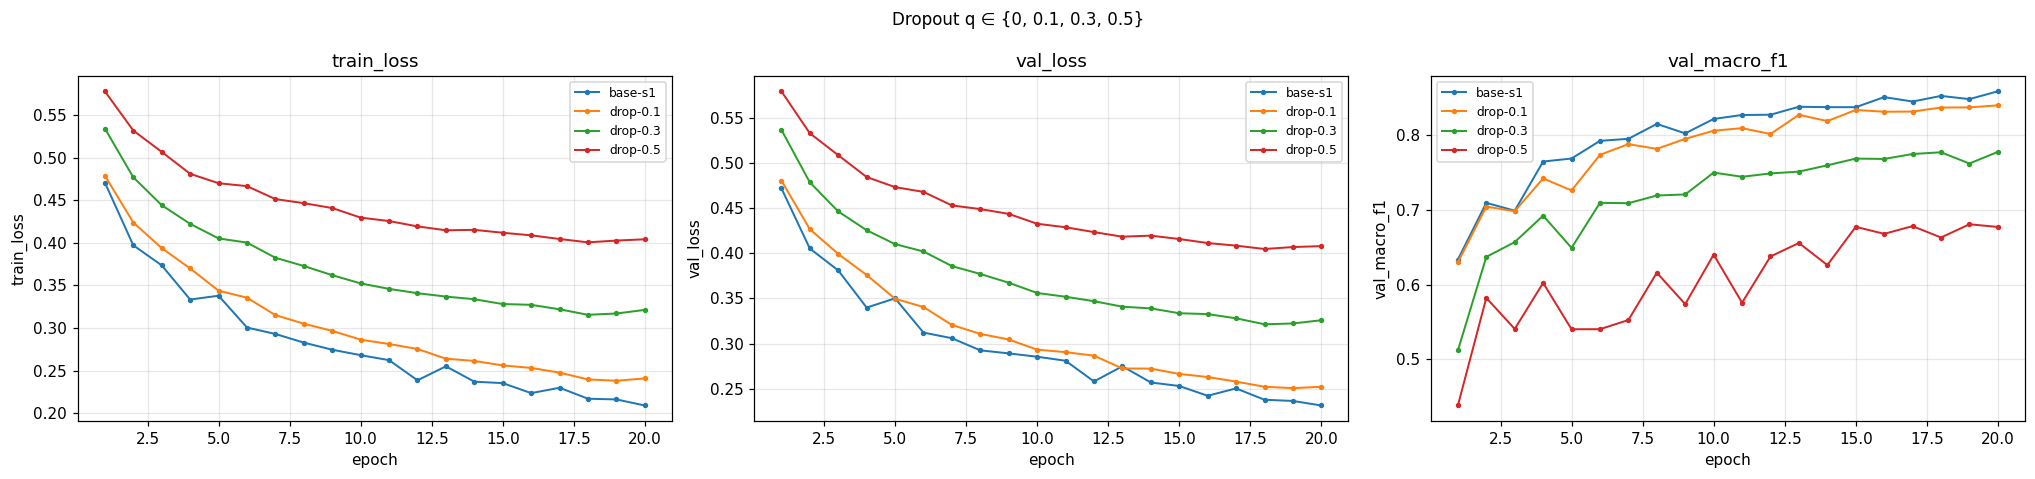

In [14]:
# Chủ đề 4 — dropout q (xác suất TẮT) sau mỗi ReLU ẩn. Train loss đo ở eval() nên so được với val.
DROP_IDS = []
for q in (0.1, 0.3, 0.5):
    run({**BASE_CFG, "exp_id": f"drop-{q:g}", "group": "dropout", "dropout": q,
         "description": f"dropout q={q:g} sau mỗi ReLU ẩn"})
    DROP_IDS.append(f"drop-{q:g}")
report(["base-s1"] + DROP_IDS)
for i in ["base-s1"] + DROP_IDS:
    s = RESULTS[i]["summary"]
    print(f"{i:>8}: khoảng cách val - train loss ở epoch cuối = {s['final_val_loss'] - s['final_train_loss']:+.4f}")
plot_compare([RESULTS[i] for i in ["base-s1"] + DROP_IDS], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_dropout.png", "Dropout q ∈ {0, 0.1, 0.3, 0.5}")
display(Image(f"{OUT_DIR}/figures/compare_dropout.png"))

**Đối chiếu sau khi chạy:** khớp về hướng, nhưng ngay q = 0,1 cũng giảm rõ chứ không nằm trong nhiễu. Val macro-F1 là 0,8368 / 0,7769 / 0,6630 với q = 0,1 / 0,3 / 0,5 (Δ = −0,019 / −0,079 / −0,193, đều vượt 2σ). Khoảng cách val − train loss ở epoch cuối giảm từ 0,0223 (baseline) xuống 0,0113 / 0,0046 / 0,0038, nhưng là vì train loss tăng (0,2091 → 0,2409 / 0,3213 / 0,4042), còn val loss cũng tăng theo. Dropout đúng là làm giảm khoảng cách train–val, nhưng model này đang underfit nên cái giá là mất dung lượng. Các lớp nhỏ chịu thiệt nhất: acc chỉ giảm 0,011–0,081 trong khi macro-F1 giảm 0,019–0,193. Dropout chỉ đáng dùng khi val loss tăng lại trong lúc train loss vẫn giảm, ví dụ với model rộng hơn hoặc huấn luyện lâu hơn (thử lại ở cấu hình cuối).

### Chủ đề 5 — Cắt gradient (`clipping`)
**Dự đoán trước:** c lấy bằng trung vị grad_norm (đo trước clip) của `base-s1` (p50 ≈ 0,56; p99 ≈ 0,94; max 2,87 ở epoch 1), nên clip sẽ kích hoạt ở khoảng một nửa số bước. Ở lr 0,1 baseline vốn ổn định, nên clip chỉ làm một số bước ngắn lại và F1 nằm trong nhiễu. Ở lr cao (×10 trở lên), không clip sẽ có những bước gradient rất lớn làm loss nhảy vọt hoặc ra NaN. Clip giới hạn độ dài mỗi bước ở lr·c, nên sẽ cứu được phần lớn và đưa F1 về gần baseline.

grad_norm mỗi bước của base-s1: p50 0.559 | p90 0.713 | p99 0.938 | max 2.871
[clip-0.56] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=0.56 | fp32 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.4580 | val 0.4590 acc 0.8070 f1 0.6441 | gn 0.567 (max 2.871) | 1.52s
  ep  5/20 | train 0.3422 | val 0.3520 acc 0.8518 f1 0.7638 | gn 0.638 (max 1.368) | 1.23s
  ep 10/20 | train 0.2751 | val 0.2891 acc 0.8828 f1 0.8127 | gn 0.614 (max 1.076) | 1.25s
  ep 15/20 | train 0.2316 | val 0.2479 acc 0.9007 f1 0.8392 | gn 0.612 (max 1.117) | 1.29s
  ep 20/20 | train 0.2170 | val 0.2381 acc 0.9064 f1 0.8522 | gn 0.606 (max 1.101) | 1.24s
  -> best epoch 18 | best val loss 0.2303 | val acc 0.9089 | val macro-F1 0.8548 | 1.32s/epoch
tỉ lệ bước bị clip mỗi epoch: [0.4, 0.56, 0.63, 0.66, 0.68, 0.68, 0.68, 0.69, 0.65, 0.68, 0.69, 0.67, 0.67, 0.64, 0.66, 0.64, 0.65, 0.66, 0.67, 0.64]
[clip-none-lr1] ce | sgd_momentum lr=1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=non

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.3072,174.6509,16.8027,False,0.0021,Không
clip-0.56,2.2691,18,0.2303,0.2170,0.2381,0.9089,0.8548,1.3199,178.7759,16.8027,False,-0.0014,Không
clip-none-lr1,2.2691,15,0.3582,0.3954,0.4108,0.8578,0.7670,1.3407,178.9590,16.8027,False,-0.0893,Có
clip-0.56-lr1,2.2691,15,0.3199,0.3528,0.3681,0.8795,0.8075,1.2932,179.1421,16.8027,False,-0.0488,Có


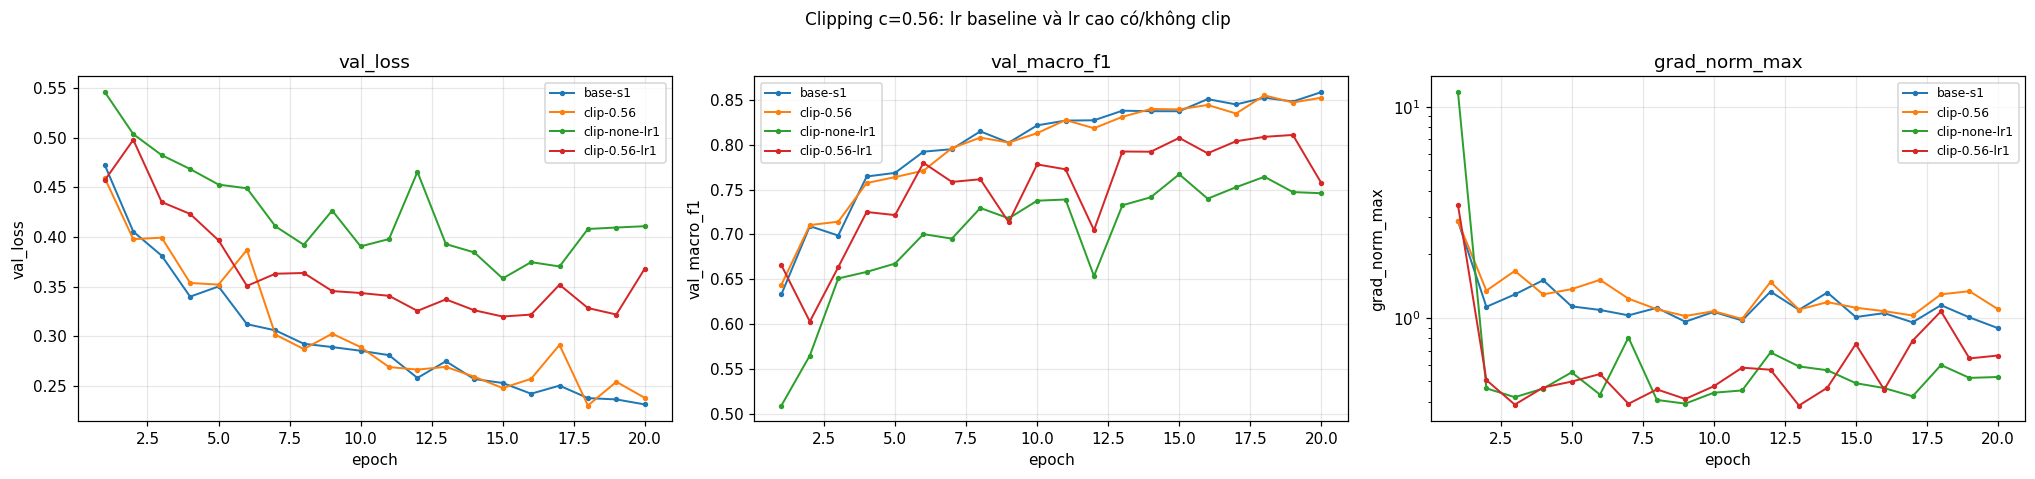

In [15]:
# Chủ đề 5 — clipping: chọn c từ phân phối grad_norm (trước clip) của baseline, để clip THỰC SỰ kích hoạt.
s = RESULTS["base-s1"]["summary"]
print(f"grad_norm mỗi bước của base-s1: p50 {s['grad_norm_p50']:.3f} | p90 {s['grad_norm_p90']:.3f} | "
      f"p99 {s['grad_norm_p99']:.3f} | max {s['grad_norm_max']:.3f}")
CLIP_C = float(f"{s['grad_norm_p50']:.2g}")      # ≈ trung vị -> clip ở khoảng một nửa số bước
CLIP_IDS = [f"clip-{CLIP_C:g}"]
run({**BASE_CFG, "exp_id": CLIP_IDS[0], "group": "clipping", "clip_norm": CLIP_C,
     "description": f"clip_norm c={CLIP_C:g} (≈ trung vị grad_norm của baseline), lr baseline"})
print("tỉ lệ bước bị clip mỗi epoch:", np.round(RESULTS[CLIP_IDS[0]]["history"]["clip_frac"], 2).tolist())

# Phản chứng: tăng lr tới khi KHÔNG clip thì mất ổn định (NaN hoặc val macro-F1 kém hẳn), rồi chạy cùng lr đó CÓ clip.
for mult in (10, 30, 100):
    HIGH_LR = BASE_LR * mult
    exp_id = f"clip-none-lr{HIGH_LR:g}"
    r = run({**BASE_CFG, "exp_id": exp_id, "group": "clipping", "lr": HIGH_LR,
             "description": f"lr ×{mult} = {HIGH_LR:g}, KHÔNG clip (tìm lr gây mất ổn định)"})
    CLIP_IDS.append(exp_id)
    if r["summary"]["diverged"] or f1(exp_id) < BASE_F1_MEAN - 0.05:
        break
exp_id = f"clip-{CLIP_C:g}-lr{HIGH_LR:g}"
run({**BASE_CFG, "exp_id": exp_id, "group": "clipping", "lr": HIGH_LR, "clip_norm": CLIP_C,
     "description": f"lr ×{mult} = {HIGH_LR:g}, CÓ clip c={CLIP_C:g}"})
CLIP_IDS.append(exp_id)
report(["base-s1"] + CLIP_IDS)
plot_compare([RESULTS[i] for i in ["base-s1"] + CLIP_IDS], ["val_loss", "val_macro_f1", "grad_norm_max"],
             f"{OUT_DIR}/figures/compare_clipping.png", f"Clipping c={CLIP_C:g}: lr baseline và lr cao có/không clip")
display(Image(f"{OUT_DIR}/figures/compare_clipping.png"))

**Đối chiếu sau khi chạy:** khớp ở lr baseline, chỉ khớp một phần ở lr cao.
- `clip-0.56` (lr 0,1): clip thật sự kích hoạt (40% số bước ở epoch 1, 56–69% ở các epoch sau) nhưng F1 = 0,8548 (Δ = −0,0014, trong 2σ). Ở lr này bước cập nhật vốn đã ổn, chặn độ dài gradient chỉ làm một số bước ngắn lại chút ít.
- `clip-none-lr1` (lr × 10 = 1, không clip): không ra NaN nhưng mất ổn định. grad_norm vọt lên 11,7 ở epoch 1, val F1 dao động mạnh (rơi từ 0,739 ở epoch 11 xuống 0,654 ở epoch 12), và tốt nhất chỉ 0,7670 (Δ = −0,089). Vòng lặp dừng ở ×10 vì F1 đã kém baseline hơn 0,05.
- `clip-0.56-lr1` (cùng lr 1, có clip): 0,8075, hơn bản không clip 0,04 (1 seed) nhưng vẫn kém baseline 0,049. **Khác dự đoán**: clip không cứu được hết. Theo `results/clip-0.56-lr1.json`, clip chỉ kích hoạt ở 3% số bước của epoch 1 và 0% sau đó, vì ở lr 1 grad_norm điển hình chỉ ≈ 0,25 (p50), nhỏ hơn c. Clip chặn được các spike đầu (grad_norm đo trước clip cao nhất 3,4 thay vì 11,7), và phần lợi đến từ đó. Dao động về sau là do lr quá lớn so với độ cong của loss chứ không do gradient lớn, nên clip theo độ dài gradient không chạm tới.
- Kết luận: clipping chống các bước bùng nổ (spike), không thay thế được việc chọn lr đúng.

### Chủ đề 6 — Mixed precision (`amp`): FP16, BF16
**Dự đoán trước:** val macro-F1 không đổi (trong nhiễu): tham số và bước cập nhật vẫn ở FP32, và GradScaler giữ cho gradient FP16 không bị underflow. Thời gian sẽ **không** nhanh hơn FP32, có thể còn chậm hơn: M-base chỉ có 47 879 tham số với lô 512, mỗi phép nhân ma trận quá nhỏ để Tensor Core của T4 tạo khác biệt, nên thời gian bị chi phối bởi chi phí khởi chạy kernel. Autocast còn thêm các kernel ép kiểu, GradScaler thêm unscale và kiểm tra inf mỗi bước. T4 (sm75) không có phần cứng BF16 nên BF16 chạy giả lập, cũng không nhanh hơn. Bộ nhớ thêm gần như không đổi vì activation của model này rất nhỏ.

GPU Tesla T4 | compute capability 7.5 | BF16 phần cứng: False
[amp-fp16] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | fp16 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.4772 | val 0.4781 acc 0.7915 f1 0.6188 | gn 0.530 (max 2.871) | 2.19s
  ep  5/20 | train 0.3447 | val 0.3569 acc 0.8486 f1 0.7614 | gn 0.582 (max 1.185) | 1.68s
  ep 10/20 | train 0.2600 | val 0.2770 acc 0.8868 f1 0.8260 | gn 0.582 (max 1.071) | 1.67s
  ep 15/20 | train 0.2279 | val 0.2444 acc 0.9028 f1 0.8470 | gn 0.573 (max 1.010) | 1.85s
  ep 20/20 | train 0.2118 | val 0.2331 acc 0.9086 f1 0.8549 | gn 0.565 (max 1.027) | 1.73s
  -> best epoch 20 | best val loss 0.2331 | val acc 0.9086 | val macro-F1 0.8549 | 1.80s/epoch
[amp-bf16] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=he | clip=none | bf16 | seed 1 | step0 val loss 2.2691
  ep  1/20 | train 0.4771 | val 0.4777 acc 0.7915 f1 0.6283 | gn 0.529 (max 2.870) | 1.47s
  ep  5/20 | train 0.3600 | val 0.372

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.3072,174.6509,16.8027,False,0.0021,Không
amp-fp16,2.2691,20,0.2331,0.2118,0.2331,0.9086,0.8549,1.8040,179.3242,16.8018,False,-0.0013,Không
amp-bf16,2.2691,20,0.2311,0.2107,0.2311,0.9085,0.8547,1.5331,179.5063,16.8008,False,-0.0015,Không


số bước GradScaler bỏ qua (gradient inf/NaN) mỗi epoch: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0]


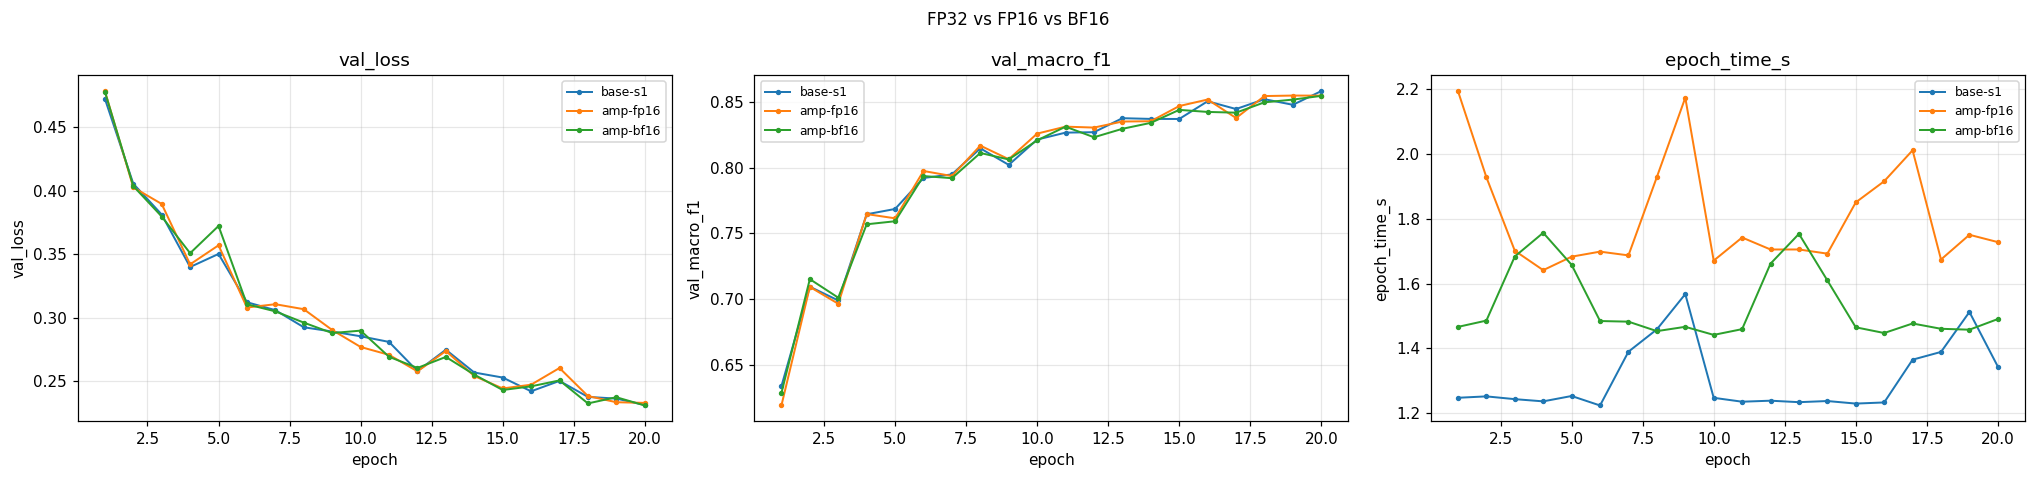

In [16]:
# Chủ đề 6 — mixed precision. Tham số vẫn FP32; autocast chỉ hạ độ chính xác của phép toán trong forward + loss.
# FP16 dùng GradScaler (scaler.unscale_ trước khi đo/clip grad_norm); BF16 không cần GradScaler.
if device == "cuda":
    cap = torch.cuda.get_device_capability()
    try:
        bf16_native = torch.cuda.is_bf16_supported(including_emulation=False)
    except TypeError:
        bf16_native = cap >= (8, 0)
    print(f"GPU {torch.cuda.get_device_name(0)} | compute capability {cap[0]}.{cap[1]} | BF16 phần cứng: {bf16_native}")
else:
    bf16_native = False
    print("không có GPU: autocast chạy trên CPU, thời gian/bộ nhớ không đại diện cho GPU")
AMP_NOTES = {"fp16": "autocast fp16 + GradScaler; unscale_ mọi bước trước khi đo grad_norm",
             "bf16": "autocast bf16, không GradScaler" + ("" if bf16_native else
                     "; GPU không có phần cứng BF16 (T4 = sm75) nên chạy bằng giả lập, không đại diện tốc độ BF16")}
AMP_IDS = []
for prec in ("fp16", "bf16"):
    try:
        run({**BASE_CFG, "exp_id": f"amp-{prec}", "group": "amp", "precision": prec,
             "description": f"mixed precision {prec} (autocast)", "notes": AMP_NOTES[prec]})
        AMP_IDS.append(f"amp-{prec}")
    except Exception as e:      # ví dụ GPU/PyTorch không hỗ trợ: ghi lý do vào báo cáo
        print(f"amp-{prec} không chạy được: {type(e).__name__}: {e}")
report(["base-s1"] + AMP_IDS)
if "amp-fp16" in RESULTS:
    print("số bước GradScaler bỏ qua (gradient inf/NaN) mỗi epoch:", RESULTS["amp-fp16"]["history"]["amp_skipped"])
plot_compare([RESULTS[i] for i in ["base-s1"] + AMP_IDS], ["val_loss", "val_macro_f1", "epoch_time_s"],
             f"{OUT_DIR}/figures/compare_amp.png", "FP32 vs FP16 vs BF16")
display(Image(f"{OUT_DIR}/figures/compare_amp.png"))

**Đối chiếu sau khi chạy:** khớp.
- Độ chính xác: val macro-F1 FP16 0,8549, BF16 0,8547 (Δ = −0,0013 / −0,0015 so với trung bình baseline, trong 2σ).
- Thời gian/epoch: 1,31 s (FP32, `base-s1`), 1,80 s (FP16, chậm hơn 38%), 1,53 s (BF16, chậm hơn 17%).
- Bộ nhớ thêm (Δmem) là 16,80 MB ở cả ba. Activation khi train với lô 512 qua M-base chỉ cỡ 1–2 MB. Đỉnh bộ nhớ nhiều khả năng nằm ở bước evaluate (lô 8 192, chạy FP32 ngoài autocast), nên không phụ thuộc precision. Δmem của M-wide tăng gấp đôi cũng khớp với cách giải thích này.
- GradScaler bỏ qua 4 bước (ở epoch 9, 12, 16, 19) vì gradient FP16 bị inf. Khoảng cách ~3 epoch ≈ 2 000 bước khớp với chu kỳ mặc định mà GradScaler thử tăng scale (`growth_interval` = 2 000): tăng scale → tràn → bỏ bước và giảm scale. Ảnh hưởng không đáng kể.
- BF16 nhanh hơn FP16 có lẽ vì không cần GradScaler. Đây là phỏng đoán, chưa đo riêng từng phần.
- Mixed precision chỉ có lợi khi phép nhân ma trận đủ lớn để GPU bận (mạng hoặc lô lớn hơn nhiều), không phải trường hợp này.

### Chủ đề 7 — Khởi tạo (`init`): zeros, normal(0,01), xavier so với He
**Dự đoán trước:**
- `zeros`: mọi kích hoạt ẩn = ReLU(0) = 0 và W3 = 0, nên gradient của W1, b1, W2, b2, W3 đều bằng 0 và chỉ b3 học được. Các nơ-ron trong cùng một lớp mãi đối xứng, nên mạng chỉ học được tần suất lớp và luôn đoán lớp đa số: acc ≈ 0,4876, macro-F1 ≈ 0,09.
- `normal(0; 0,01)`: std kích hoạt co lại ~10 lần mỗi lớp (0,01·√(n_vào/2) ≈ 0,1 với n_vào = 256), logit ≈ 0 nên loss bước 0 ≈ ln 7. Gradient các lớp đầu rất nhỏ nên khởi đầu chậm; nhưng mạng chỉ có 3 lớp nên vẫn hồi phục trong 20 epoch, kết quả kém He một chút.
- `xavier` (`xavier_normal_`, Var = 2/(n_vào + n_ra)): không bù hệ số 1/2 của ReLU như He, nên std kích hoạt giảm dần qua từng lớp. Với 3 lớp thì giảm ít, nên kết quả ngang He, trong nhiễu.

,std z1,std z2,std logits,loss bước 0
init,,,,
he,0.6609,0.6404,0.5773,2.2691
xavier,0.2758,0.2182,0.1916,2.0222
normal,0.0343,0.0038,0.0003,1.9460
zeros,0.0000,0.0000,0.0000,1.9459
default,0.2737,0.1130,0.0585,1.9830


[init-zeros] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=zeros | clip=none | fp32 | seed 1 | step0 val loss 1.9459
  ep  1/20 | train 1.2035 | val 1.2053 acc 0.4876 f1 0.0936 | gn 0.040 (max 0.498) | 1.42s
  ep  5/20 | train 1.2038 | val 1.2055 acc 0.4876 f1 0.0936 | gn 0.033 (max 0.104) | 1.22s
  ep 10/20 | train 1.2037 | val 1.2055 acc 0.4876 f1 0.0936 | gn 0.034 (max 0.097) | 1.33s
  ep 15/20 | train 1.2037 | val 1.2055 acc 0.4876 f1 0.0936 | gn 0.034 (max 0.096) | 1.20s
  ep 20/20 | train 1.2036 | val 1.2056 acc 0.4876 f1 0.0936 | gn 0.035 (max 0.114) | 1.25s
  -> best epoch 14 | best val loss 1.2052 | val acc 0.4876 | val macro-F1 0.0936 | 1.30s/epoch
[init-normal] ce | sgd_momentum lr=0.1 wd=0 | batch 512 | 256-128 drop=0 init=normal | clip=none | fp32 | seed 1 | step0 val loss 1.9460
  ep  1/20 | train 0.5652 | val 0.5669 acc 0.7557 f1 0.4803 | gn 0.304 (max 0.792) | 1.54s
  ep  5/20 | train 0.3972 | val 0.4029 acc 0.8310 f1 0.6989 | gn 0.640 (max 1.438) | 1.

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.3072,174.6509,16.8027,False,0.0021,Không
init-zeros,1.9459,14,1.2052,1.2036,1.2056,0.4876,0.0936,1.2958,179.8745,16.8027,False,-0.7626,Có
init-normal,1.9460,19,0.2400,0.2415,0.2580,0.9028,0.8485,1.3228,180.0576,16.8027,False,-0.0077,Có
init-xavier,2.0222,18,0.2300,0.2138,0.2345,0.9094,0.8585,1.3260,180.2407,16.8027,False,0.0023,Không


init=zeros, grad norm từng tham số sau 1 backward: {'net.0.weight': 0.0, 'net.0.bias': 0.0, 'net.2.weight': 0.0, 'net.2.bias': 0.0, 'net.4.weight': 0.0, 'net.4.bias': 0.496712}


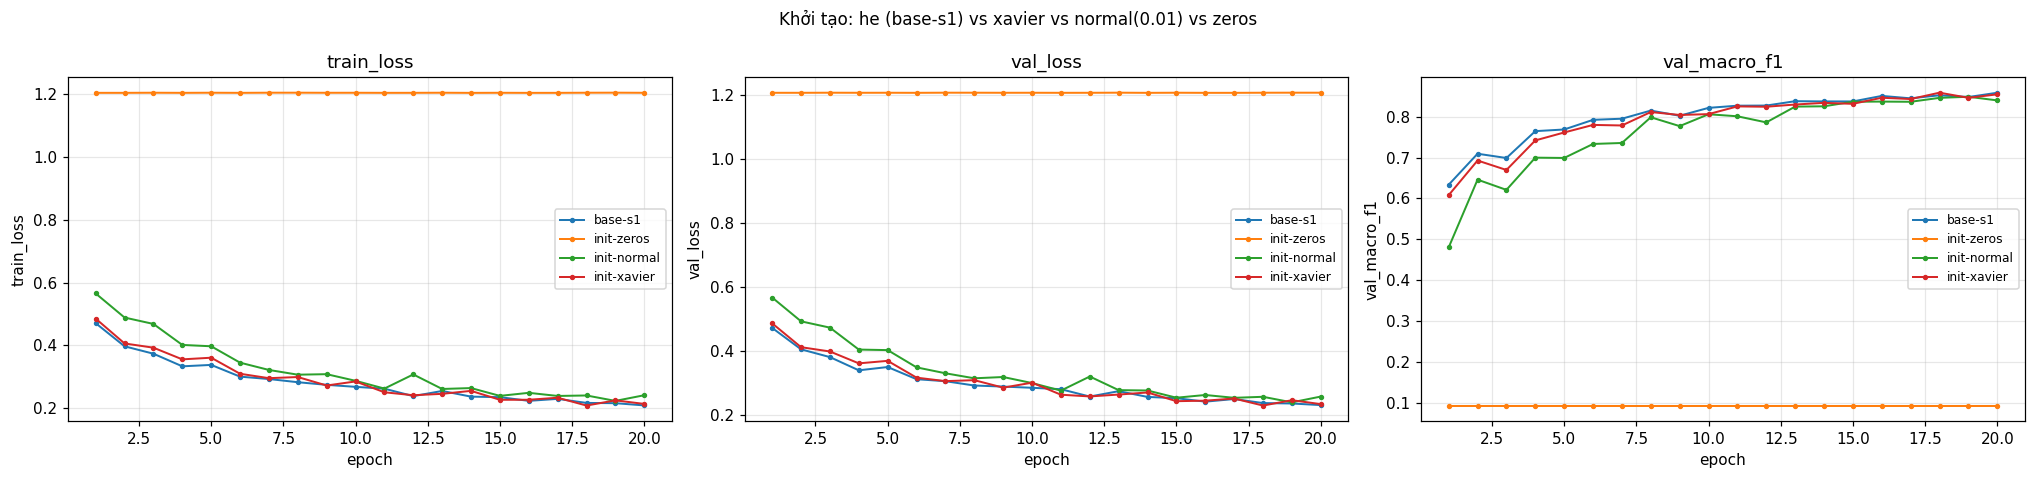

In [17]:
# Chủ đề 7 — khởi tạo (bias = 0). xavier = nn.init.xavier_normal_: Var[W] = 2/(n_vào + n_ra); he: Var[W] = 2/n_vào.
# Bước 0: độ lệch chuẩn kích hoạt sau mỗi Linear (lô val 4096 mẫu) và loss bước 0 cho từng cách khởi tạo.
rows = []
for init in ("he", "xavier", "normal", "zeros", "default"):
    set_seed(1)
    m0 = MLP(hidden=(256, 128), init=init).to(device).eval()
    with torch.no_grad():
        l0 = F.cross_entropy(m0(data["X_val"]), data["y_val"]).item()
    z1, z2, z3 = activation_stats(m0, data["X_val"][:4096])
    rows.append({"init": init, "std z1": z1, "std z2": z2, "std logits": z3, "loss bước 0": l0})
display(pd.DataFrame(rows).set_index("init").round(4))

INIT_IDS = []
for init in ("zeros", "normal", "xavier"):
    run({**BASE_CFG, "exp_id": f"init-{init}", "group": "init", "init": init,
         "description": f"khởi tạo {init} thay cho He (bias = 0)"})
    INIT_IDS.append(f"init-{init}")
report(["base-s1"] + INIT_IDS)

# zeros: mọi kích hoạt ẩn = ReLU(0) = 0 và W3 = 0, nên sau một backward chỉ b3 có gradient khác 0
# -> mạng chỉ học được tần suất lớp (luôn đoán lớp đa số), các nơ-ron cùng lớp mãi đối xứng
set_seed(1)
mz = MLP(hidden=(256, 128), init="zeros").to(device)
F.cross_entropy(mz(data["X_tr"][:512]), data["y_tr"][:512]).backward()
print("init=zeros, grad norm từng tham số sau 1 backward:",
      {n: round(p.grad.norm().item(), 6) for n, p in mz.named_parameters()})
plot_compare([RESULTS[i] for i in ["base-s1"] + INIT_IDS], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_init.png", "Khởi tạo: he (base-s1) vs xavier vs normal(0.01) vs zeros")
display(Image(f"{OUT_DIR}/figures/compare_init.png"))

**Đối chiếu sau khi chạy:** khớp.
- Bước 0 (bảng trên): std kích hoạt sau z1 / z2 / logits là 0,66 / 0,64 / 0,58 với He (gần như giữ nguyên qua các lớp), 0,28 / 0,22 / 0,19 với Xavier (giảm ~0,8 lần mỗi lớp), 0,034 / 0,0038 / 0,0003 với normal(0,01) (giảm ~10 lần mỗi lớp), và 0 với zeros. Loss bước 0 tương ứng là 2,269 / 2,022 / 1,946 / 1,946: logit càng gần 0 thì loss càng gần ln 7.
- `init-zeros`: acc 0,4876 và macro-F1 0,0936 suốt 20 epoch, đúng mốc đoán đa số. Sau một backward chỉ b3 có gradient (norm 0,497), mọi tham số khác bằng 0 tuyệt đối. Val loss dừng ở 1,2052, đúng bằng entropy của phân phối lớp (1,2052), tức loss nhỏ nhất khi chỉ học được tần suất lớp. Đối xứng không bao giờ bị phá vì các nơ-ron trong cùng lớp nhận đúng cùng một gradient (ở đây là 0).
- `init-normal`: khởi đầu chậm (F1 epoch 1 = 0,48 so với 0,63 của He; grad_norm trung bình epoch 1 = 0,30 so với 0,53), rồi đuổi kịp phần lớn: 0,8485 (Δ = −0,0077, vượt 2σ nhưng chỉ 1 seed).
- `init-xavier`: 0,8585 (Δ = +0,0023, trong 2σ), không phân biệt được với He. Với 3 lớp, giảm ~0,8 lần mỗi lớp chưa đủ gây vanishing. Trong mạng 30 lớp như slide thì 0,8³⁰ ≈ 0,001, và khi đó chọn He hay Xavier mới quyết định.

### Cấu hình cuối cùng — chọn CHỈ bằng val
Kết hợp bộ tối ưu + lr tốt nhất (theo val, trong mọi lần chạy chủ đề optimizer) với M-base / M-wide và dropout {0; 0,1}, huấn luyện 60 epoch với lr giảm theo cosine.
Ứng viên tốt nhất theo val macro-F1 được chạy thêm 2 seed. Tập eval chỉ được dùng ở Part 4, sau khi đã chốt cấu hình.

**Dự đoán trước:** baseline, M-wide và M-deep đều còn giảm loss ở epoch 20, nên phần lợi lớn nhất sẽ đến từ 60 epoch + cosine (lr giảm dần về 0 giúp hội tụ sâu ở cuối và bớt răng cưa). AdamW lr 3e-3 đã hơn baseline +0,02 ngay ở 20 epoch. Dự đoán ứng viên tốt nhất đạt val macro-F1 khoảng 0,90–0,92 (vượt xa 2σ), và M-wide hơn M-base như ở Chủ đề 3. Với 60 epoch và model rộng thì có thể bắt đầu quá khớp, nên dropout 0,1 có thể giúp M-wide; với M-base thì có lẽ vẫn hại như ở Chủ đề 4.

optimizer + lr tốt nhất theo val: opt-adamw-lr0.003 (val macro-F1 0.8757)
[final-base-d0-s1] ce | adamw lr=0.003 wd=0.01 | batch 512 | 256-128 drop=0 init=he | clip=none | fp32 | seed 1 | sched=cosine | step0 val loss 2.2691
  ep  1/60 | train 0.4348 | val 0.4356 acc 0.8164 f1 0.6652 | gn 0.609 (max 2.871) | 1.79s
  ep  5/60 | train 0.2792 | val 0.2924 acc 0.8810 f1 0.8108 | gn 0.665 (max 1.631) | 1.38s
  ep 10/60 | train 0.2397 | val 0.2569 acc 0.8951 f1 0.8428 | gn 0.675 (max 1.353) | 1.65s
  ep 15/60 | train 0.2146 | val 0.2347 acc 0.9042 f1 0.8585 | gn 0.681 (max 1.458) | 1.38s
  ep 20/60 | train 0.1855 | val 0.2119 acc 0.9155 f1 0.8782 | gn 0.672 (max 1.349) | 1.82s
  ep 25/60 | train 0.1683 | val 0.1951 acc 0.9219 f1 0.8855 | gn 0.684 (max 1.371) | 1.40s
  ep 30/60 | train 0.1570 | val 0.1872 acc 0.9258 f1 0.8885 | gn 0.674 (max 2.055) | 1.63s
  ep 35/60 | train 0.1404 | val 0.1728 acc 0.9324 f1 0.8957 | gn 0.666 (max 1.258) | 1.38s
  ep 40/60 | train 0.1284 | val 0.1623 acc 0.93

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
final-base-d0-s1,2.2691,60,0.1494,0.1114,0.1494,0.9429,0.9116,1.4927,180.9731,16.9858,False,0.0553,Có
final-base-d0.1-s1,2.2691,60,0.1713,0.1500,0.1713,0.9336,0.8973,1.6075,181.1562,16.9858,False,0.0411,Có
final-wide-d0-s1,1.9182,57,0.1133,0.0577,0.1134,0.9576,0.9300,1.5129,199.5024,34.7163,False,0.0738,Có
final-wide-d0.1-s1,1.9182,60,0.1230,0.0902,0.1230,0.9517,0.9249,1.6458,200.1182,34.7163,False,0.0687,Có


cấu hình cuối (theo val macro-F1): final-wide-d0-s1
[final-wide-d0-s2] ce | adamw lr=0.003 wd=0.01 | batch 512 | 512-256 drop=0 init=he | clip=none | fp32 | seed 2 | sched=cosine | step0 val loss 2.6520
  ep  1/60 | train 0.4118 | val 0.4178 acc 0.8229 f1 0.7152 | gn 0.696 (max 4.772) | 1.45s
  ep  5/60 | train 0.2463 | val 0.2610 acc 0.8948 f1 0.8409 | gn 0.590 (max 1.265) | 1.70s
  ep 10/60 | train 0.1976 | val 0.2228 acc 0.9087 f1 0.8540 | gn 0.582 (max 1.097) | 1.43s
  ep 15/60 | train 0.1648 | val 0.1948 acc 0.9213 f1 0.8762 | gn 0.561 (max 0.995) | 1.83s
  ep 20/60 | train 0.1493 | val 0.1816 acc 0.9279 f1 0.8894 | gn 0.538 (max 0.969) | 1.43s
  ep 25/60 | train 0.1308 | val 0.1701 acc 0.9332 f1 0.9029 | gn 0.532 (max 1.124) | 1.53s
  ep 30/60 | train 0.1095 | val 0.1518 acc 0.9404 f1 0.9069 | gn 0.518 (max 1.327) | 1.41s
  ep 35/60 | train 0.0966 | val 0.1420 acc 0.9449 f1 0.9177 | gn 0.503 (max 0.930) | 1.42s
  ep 40/60 | train 0.0829 | val 0.1311 acc 0.9494 f1 0.9203 | gn 0.49

,step0_loss,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,s/epoch,peak_mem_MB,Δmem_MB,diverged,Δf1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
final-wide-d0-s1,1.9182,57,0.1133,0.0577,0.1134,0.9576,0.9300,1.5129,199.5024,34.7163,False,0.0738,Có
final-wide-d0-s2,2.6520,58,0.1169,0.0624,0.1169,0.9563,0.9280,1.5050,200.7339,34.7163,False,0.0718,Có
final-wide-d0-s3,2.7882,59,0.1161,0.0613,0.1161,0.9563,0.9296,1.5060,201.3496,34.7163,False,0.0734,Có


cấu hình cuối: val macro-F1 0.9292 ± 0.0011 (3 seed) | baseline 0.8562 ± 0.0019 | chênh +0.0730


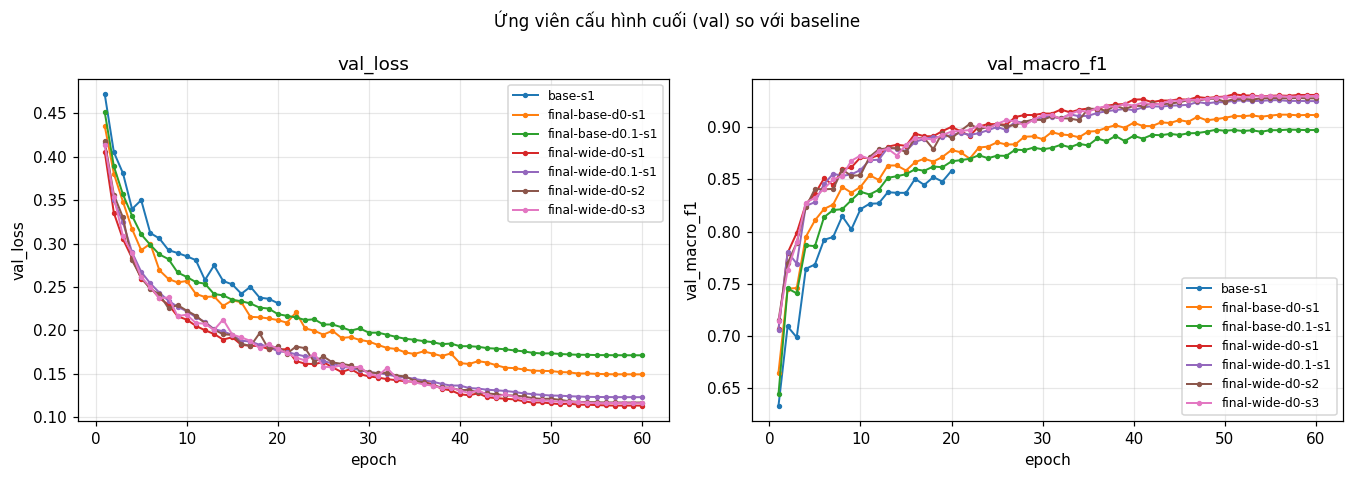

In [18]:
best_opt_id = max([i for ids in OPT_IDS.values() for i in ids], key=f1)
oc = RESULTS[best_opt_id]["cfg"]
FINAL_BASE = {**BASE_CFG, "group": "final", "optimizer": oc["optimizer"], "lr": oc["lr"],
              "weight_decay": oc["weight_decay"], "epochs": 60, "scheduler": "cosine"}
print(f"optimizer + lr tốt nhất theo val: {best_opt_id} (val macro-F1 {f1(best_opt_id):.4f})")

CANDS = []
for size, hidden in (("base", (256, 128)), ("wide", (512, 256))):
    for q in (0.0, 0.1):
        exp_id = f"final-{size}-d{q:g}-s1"
        run({**FINAL_BASE, "exp_id": exp_id, "hidden": hidden, "dropout": q, "seed": 1,
             "description": f"ứng viên cuối: {oc['optimizer']} lr={oc['lr']:g}, {size}, dropout {q:g}, 60 epoch, cosine"})
        CANDS.append(exp_id)
report(CANDS)
FINAL_ID = max(CANDS, key=f1)
FINAL_CFG = RESULTS[FINAL_ID]["cfg"]
print("cấu hình cuối (theo val macro-F1):", FINAL_ID)

FINAL_IDS = [FINAL_ID]
for seed in (2, 3):
    exp_id = FINAL_ID.replace("-s1", f"-s{seed}")
    run({**FINAL_CFG, "exp_id": exp_id, "seed": seed, "description": f"{FINAL_CFG['description']}, seed {seed}"})
    FINAL_IDS.append(exp_id)
report(FINAL_IDS)
ff = np.array([f1(i) for i in FINAL_IDS])
print(f"cấu hình cuối: val macro-F1 {ff.mean():.4f} ± {ff.std(ddof=1):.4f} (3 seed) | "
      f"baseline {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f} | chênh {ff.mean() - BASE_F1_MEAN:+.4f}")
plot_compare([RESULTS[i] for i in ["base-s1"] + CANDS + FINAL_IDS[1:]], ["val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_final.png", "Ứng viên cấu hình cuối (val) so với baseline")
display(Image(f"{OUT_DIR}/figures/compare_final.png"))

**Đối chiếu sau khi chạy:** khớp về hướng và vượt mức dự đoán, nhưng dropout không giúp như kỳ vọng.
- Ứng viên (seed 1): `final-base-d0-s1` 0,9116; `final-base-d0.1-s1` 0,8973; `final-wide-d0-s1` **0,9300**; `final-wide-d0.1-s1` 0,9249. Chọn `final-wide-d0-s1` theo val macro-F1.
- 3 seed của cấu hình cuối: 0,9292 ± 0,0011, hơn baseline (0,8562 ± 0,0019) là +0,0730, gấp ~20 lần ngưỡng 2σ. Đây là cải thiện thật chứ không phải nhiễu.
- Phần lớn lợi ích đến từ huấn luyện lâu hơn với lr giảm dần: cùng M-base và AdamW 3e-3, `final-base-d0-s1` (60 epoch, cosine) hơn `opt-adamw-lr0.003` (20 epoch) 0,036. Mạng rộng hơn thêm +0,018 (0,9300 so với 0,9116). Best epoch là 57–60 vì lr cosine về 0 ở cuối nên đường val phẳng dần.
- Dropout 0,1 vẫn hại ở cả hai kích thước (−0,014 với M-base, −0,005 với M-wide). Với M-wide, khoảng cách val − train loss đã lên 0,056 (0,1134 − 0,0577), nhưng val loss vẫn giảm tới epoch 57, nên model chưa quá khớp tới mức dropout có ích. Mức −0,005 chỉ hơi vượt 2σ với 1 seed, nên chưa kết luận chắc.
- Hạn chế: cấu hình cuối đổi nhiều yếu tố cùng lúc (optimizer, lr, số epoch, scheduler, độ rộng), nên +0,073 là hiệu ứng tổng; phần tách riêng ở trên chỉ dựa trên 1 seed mỗi ứng viên. Cấu hình được chọn hoàn toàn bằng val; eval chỉ được dùng ở Part 4.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [19]:
# Part 4b: đánh giá trên eval MỘT LẦN cho baseline (base-s1) và cấu hình cuối (FINAL_ID), cả hai đã chốt bằng val.
# Kết quả đọc lại từ JSON không có trọng số -> chạy lại đúng cfg đó (cùng seed) để có best_state.
def with_weights(exp_id):
    if RESULTS[exp_id].get("best_state") is None:
        run(RESULTS[exp_id]["cfg"], force=True)
    return RESULTS[exp_id]


base_res, final_res = with_weights("base-s1"), with_weights(FINAL_ID)
# baseline ghi ra thư mục riêng: không lẫn vào results/ (load_results đọc mọi *.json ở đó) và không đè file nộp
EVAL_BASE = final_eval(base_res["cfg"], base_res, data, f"{OUT_DIR}/eval_baseline/predictions_eval.csv",
                       f"{OUT_DIR}/eval_baseline/eval_result.json", repo_root=REPO_ROOT)
EVAL_FINAL = final_eval(final_res["cfg"], final_res, data, f"{OUT_DIR}/predictions_eval.csv",
                        f"{OUT_DIR}/eval_result.json", repo_root=REPO_ROOT)
EVAL_SCORES = {"base-s1": EVAL_BASE, FINAL_ID: EVAL_FINAL}
display(pd.DataFrame({k: {"eval_acc": v["accuracy"], "eval_macro_f1": v["macro_f1"]}
                      for k, v in EVAL_SCORES.items()}).T.round(4))
print(f"eval macro-F1: cấu hình cuối - baseline = {EVAL_FINAL['macro_f1'] - EVAL_BASE['macro_f1']:+.4f}")

n_eval = 116203
accuracy = 0.9064
macro_f1 = 0.8618   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9115  0.8912  0.9012
  1    56661     0.9092  0.9332  0.9211
  2     7151     0.9008  0.8990  0.8999
  3      549     0.8381  0.8015  0.8194
  4     1899     0.8357  0.7125  0.7692
  5     3473     0.8275  0.7777  0.8018
  6     4102     0.9230  0.9171  0.9200

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37760   4264     5    0    49     9   281
1   3338  52876   118    0   200    96    33
2      0    237  6429   65    12   408     0
3      0      2    65  440     0    42     0
4     28    483    27    0  1353     8     0
5      2    253   493   20     4  2701     0
6    300     39     0    0     1     0  3762

đã ghi /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602505/eval_baseline/eval_result.json

n_eval = 116203
accuracy = 0.9571
macro_f1 = 0.9342   <- chỉ số chính

lớp  support  pre

,eval_acc,eval_macro_f1
base-s1,0.9064,0.8618
final-wide-d0-s1,0.9571,0.9342


eval macro-F1: cấu hình cuối - baseline = +0.0723


,support,precision,recall,f1,f1_baseline
cls,,,,,
0,42368,0.9575,0.9514,0.9544,0.9012
1,56661,0.9608,0.9660,0.9634,0.9211
2,7151,0.9586,0.9575,0.9580,0.8999
3,549,0.8909,0.8780,0.8844,0.8194
4,1899,0.8981,0.8868,0.8924,0.7692
5,3473,0.9278,0.9220,0.9249,0.8018
6,4102,0.9586,0.9644,0.9615,0.9200


lớp khó nhất: 3 (F1 0.8844, support 549); hay bị nhầm thành lớp 2 (8.4% số mẫu của lớp 3)


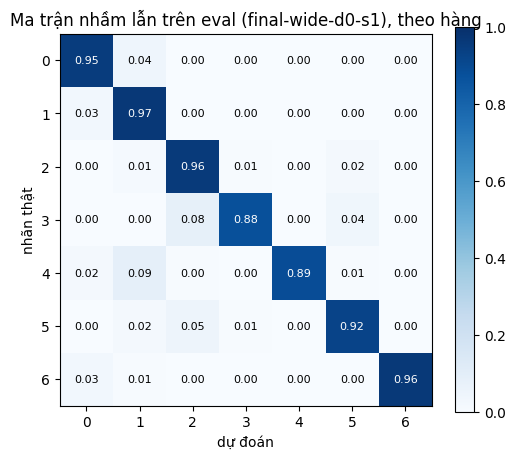

In [20]:
# Phân tích lỗi trên eval (cấu hình cuối): P/R/F1 theo lớp (kèm F1 của baseline) + ma trận nhầm lẫn chuẩn hoá theo hàng
pc = pd.DataFrame(EVAL_FINAL["per_class"]).set_index("cls")
pc["f1_baseline"] = [c["f1"] for c in EVAL_BASE["per_class"]]
display(pc.round(4))
cm = np.array(EVAL_FINAL["confusion_matrix"])
cmn = cm / cm.sum(1, keepdims=True)
hardest = int(pc["f1"].idxmin())
off = cmn[hardest].copy(); off[hardest] = 0
print(f"lớp khó nhất: {hardest} (F1 {pc.loc[hardest, 'f1']:.4f}, support {pc.loc[hardest, 'support']}); "
      f"hay bị nhầm thành lớp {int(off.argmax())} ({off.max():.1%} số mẫu của lớp {hardest})")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if cmn[i, j] > 0.5 else "black")
ax.set_xticks(range(7)); ax.set_yticks(range(7))
ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật")
ax.set_title(f"Ma trận nhầm lẫn trên eval ({FINAL_ID}), theo hàng")
fig.colorbar(im); plt.show()

**Phân tích lỗi (cấu hình cuối `final-wide-d0-s1`, trên eval):**
- Tổng: eval acc 0,9571, macro-F1 0,9342 (baseline `base-s1`: 0,9064 / 0,8618, tức +0,0723). Val macro-F1 của cùng model là 0,9300, rất gần eval, nên không có dấu hiệu cấu hình bị chọn khớp riêng vào val. F1 tăng ở mọi lớp, nhiều nhất ở các lớp nhỏ: lớp 4 (0,769 → 0,892), lớp 5 (0,802 → 0,925), lớp 3 (0,819 → 0,884).
- Lớp khó nhất là **lớp 3** (Cottonwood/Willow; tên lớp theo mô tả bộ dữ liệu UCI Covertype, nhãn đã trừ 1): F1 0,8844, chỉ 549 mẫu eval (0,47%). 46/549 = 8,4% bị đoán thành lớp 2 (Ponderosa Pine) và 21/549 = 3,8% thành lớp 5 (Douglas-fir). Ngược lại, 40 mẫu lớp 2 và 19 mẫu lớp 5 bị đoán thành lớp 3, nên precision cũng chỉ 0,891.
- Lý giải bằng dữ liệu (thống kê trên `data/processed/train.npz`, 464 809 mẫu): lớp 3 chỉ có 2 198 mẫu train, ít hơn lớp 2 (28 603) 13 lần và lớp 5 (13 894) 6 lần. Ba lớp này cùng ở độ cao thấp (Elevation trung bình 2 224 ± 102 m, 2 394 ± 196 m và 2 419 ± 189 m) và cùng nằm ở vùng hoang dã 4 (100% mẫu lớp 3, 60% lớp 2, 56% lớp 5). Hai đặc trưng tách loài cây mạnh nhất vì vậy chồng lấn. Với CE không trọng số, lớp 3 đóng góp rất ít vào loss, nên ranh giới bị kéo về phía hai lớp lớn hơn.
- Về số lượng, lỗi nhiều nhất là giữa lớp 0 (Spruce/Fir) và lớp 1 (Lodgepole Pine): 1 883 + 1 629 = 3 512 mẫu, 70% trong tổng số 4 988 lỗi. Hai lớp này có độ cao chồng lấn (3 129 ± 158 m và 2 921 ± 186 m) và cùng nằm ở vùng 1 và 3, nhưng support lớn nên F1 vẫn cao (0,954 / 0,963).
- Cách cải thiện sẽ thử: CE có trọng số theo lớp (hoặc lấy mẫu lại) cho các lớp 3, 4, 5, chọn trọng số bằng val macro-F1.

In [21]:
# Part 4a: experiments.xlsx từ results/*.json (mỗi lần chạy một dòng); eval_* chỉ cho baseline và cấu hình cuối
import glob
results = load_results(f"{OUT_DIR}/results")
rows = [to_row(r, eval_scores=EVAL_SCORES.get(r["cfg"]["exp_id"])) for r in results]
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=BASE_IDS)
print(f"đã ghi {OUT_DIR}/experiments.xlsx: {len(rows)} dòng (tối đa 60)")

# mỗi dòng đúng một ảnh figures/<exp_id>.png (ảnh compare_*.png không tính)
figs = {os.path.basename(p)[:-4] for p in glob.glob(f"{OUT_DIR}/figures/*.png")
        if not os.path.basename(p).startswith("compare_")}
ids = {r["exp_id"] for r in rows}
assert figs == ids, f"ảnh thừa: {figs - ids}, thiếu ảnh: {ids - figs}"

tab = pd.DataFrame(rows).set_index("exp_id")
tab["Δf1_vs_base"] = tab["val_macro_f1"] - BASE_F1_MEAN
tab["vượt 2σ?"] = np.where(tab["Δf1_vs_base"].abs() > NOISE_F1, "Có", "Không")
cols = ["group", "optimizer", "lr", "batch", "hidden", "dropout", "clip_norm", "precision", "init", "epochs",
        "val_acc", "val_macro_f1", "Δf1_vs_base", "vượt 2σ?", "time_per_epoch_s", "eval_macro_f1"]
display(tab[cols].round(4))
print("openpyxl không tính công thức: mở experiments.xlsx bằng Excel/Google Sheets, lưu lại, "
      "rồi viết nhận xét ở sheet Summary.")

đã ghi ../experiments.xlsx: 40 dòng (tối đa 60)


,group,optimizer,lr,batch,hidden,dropout,clip_norm,precision,init,epochs,val_acc,val_macro_f1,Δf1_vs_base,vượt 2σ?,time_per_epoch_s,eval_macro_f1
exp_id,,,,,,,,,,,,,,,,
base-s1,baseline,SGD+momentum,0.1000,512,256-128,0.0,none,fp32,he,20,0.9085,0.8584,0.0021,Không,1.3072,0.8618
base-s2,baseline,SGD+momentum,0.1000,512,256-128,0.0,none,fp32,he,20,0.9098,0.8552,-0.0010,Không,1.2880,NaN
base-s3,baseline,SGD+momentum,0.1000,512,256-128,0.0,none,fp32,he,20,0.9090,0.8551,-0.0011,Không,1.3530,NaN
loss-mse,loss,SGD+momentum,0.1000,512,256-128,0.0,none,fp32,he,20,0.8713,0.7329,-0.1233,Có,1.3838,NaN
opt-adam-lr0.0003,optimizer,Adam,0.0003,512,256-128,0.0,none,fp32,he,20,0.8761,0.7955,-0.0607,Có,1.4779,NaN
opt-adam-lr0.001,optimizer,Adam,0.0010,512,256-128,0.0,none,fp32,he,20,0.9033,0.8437,-0.0125,Có,1.4474,NaN
opt-adam-lr0.003,optimizer,Adam,0.0030,512,256-128,0.0,none,fp32,he,20,0.9178,0.8683,0.0121,Có,1.4362,NaN
opt-adam-lr0.01,optimizer,Adam,0.0100,512,256-128,0.0,none,fp32,he,20,0.9161,0.8611,0.0049,Có,1.4769,NaN
opt-adamw-lr0.001,optimizer,AdamW,0.0010,512,256-128,0.0,none,fp32,he,20,0.8997,0.8398,-0.0164,Có,1.4516,NaN


openpyxl không tính công thức: mở experiments.xlsx bằng Excel/Google Sheets, lưu lại, rồi viết nhận xét ở sheet Summary.


In [22]:
# Kiểm tra trước khi nộp
left = [f for f in glob.glob("*.py") if "NotImplementedError" in open(f, encoding="utf-8").read()]
assert not left, f"còn NotImplementedError trong {left}"
for f in ("predictions_eval.csv", "eval_result.json", "experiments.xlsx"):
    assert os.path.exists(f"{OUT_DIR}/{f}"), f"thiếu {f}"
print("ok: không còn NotImplementedError; có predictions_eval.csv, eval_result.json, experiments.xlsx; "
      f"{len(rows)} dòng = {len(figs)} ảnh")

ok: không còn NotImplementedError; có predictions_eval.csv, eval_result.json, experiments.xlsx; 40 dòng = 40 ảnh
